# FITE Classification Challenge


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

<h1 style="margin-bottom:6px;">حل تحدي التصنيف متعدد الفئات</h1>


<p>
لدينا بيانات جدولية مجهولة الخصائص: الأعمدة مسماة من <code>f1</code> إلى <code>f21</code>، والهدف هو توقع واحدة من ثلاث فئات.
بما أن معنى الأعمدة غير معروف، تعاملنا مع المسألة كمسألة اكتشاف أنماط رقمية: نحلل التوزيع، نحدد الخصائص الأكثر فائدة، ثم نقارن نماذج مختلفة بتقييم داخلي ثابت.
</p>

<div style="display:grid; grid-template-columns:repeat(auto-fit,minmax(180px,1fr)); gap:12px; margin:14px 0;">
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>التدريب</b><br><span style="font-size:22px;">3,200</span> صف</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>الاختبار</b><br><span style="font-size:22px;">3,200</span> صف</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>الخصائص</b><br><span style="font-size:22px;">21</span> عمود</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>الفئات</b><br><span style="font-size:22px;">3</span> Classes</div>
</div>

<p>
الهدف من النوتبوك ليس فقط إنتاج <code>submission.csv</code>، بل توضيح كيف انتقلنا من التحليل إلى اختيار النموذج:
أي نماذج جربنا، كيف قيمناها، وأي أدلة جعلتنا نفضل ملف رفع على آخر.
</p>


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 1. المكتبات والإعدادات


نبدأ بتجهيز مكتبات التحليل والرسم والتقييم، ثم نثبت قيمة <code>RANDOM_STATE</code> حتى تكون نتائج التقسيمات قابلة للإعادة.
هذه الخلية فقط تجهز الأدوات التي سنستخدمها في قراءة البيانات، تحليلها، ورسم النتائج.


</div>


In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
ARTIFACT_DIR = Path("classification_artifacts")

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 2. قراءة البيانات وفحص البنية


قرأنا ملفات التدريب والاختبار وملف العينة المطلوب للرفع. بعد القراءة فحصنا عدد الصفوف والأعمدة، وتأكدنا أن خصائص التدريب والاختبار لها نفس الأسماء ونفس الترتيب.

هذا الفحص بسيط لكنه مهم عملياً: قبل أي نموذج يجب التأكد أن البيانات التي ستدخل التدريب هي نفسها بالضبط التي ستدخل التنبؤ، وأن ملف الرفع سيحافظ على ترتيب <code>ID</code>.


</div>


In [2]:
train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)
sample_submission = pd.read_csv(SAMPLE_FILE)

ID_COL = "ID"
TARGET_COL = "target"
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]

assert TARGET_COL in train.columns
assert TARGET_COL not in test.columns
assert feature_cols == [c for c in test.columns if c != ID_COL]
assert sample_submission[ID_COL].tolist() == test[ID_COL].tolist()

basic_checks = pd.DataFrame({
    "الفحص": [
        "شكل train", "شكل test", "عدد الخصائص", "القيم المفقودة في train", "القيم المفقودة في test",
        "ID فريد في train", "ID فريد في test", "صفوف مكررة حسب الخصائص في train", "صفوف مكررة حسب الخصائص في test"
    ],
    "القيمة": [
        train.shape, test.shape, len(feature_cols), int(train.isna().sum().sum()), int(test.isna().sum().sum()),
        bool(train[ID_COL].is_unique), bool(test[ID_COL].is_unique), int(train[feature_cols].duplicated().sum()), int(test[feature_cols].duplicated().sum())
    ]
})

display(basic_checks)
display(train.head())
display(test.head())


,الفحص,القيمة
0,شكل train,"(3200, 23)"
1,شكل test,"(3200, 22)"
2,عدد الخصائص,21
3,القيم المفقودة في train,0
4,القيم المفقودة في test,0
5,ID فريد في train,True
6,ID فريد في test,True
7,صفوف مكررة حسب الخصائص في train,57
8,صفوف مكررة حسب الخصائص في test,7


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,0.00088,0,0,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,0.00510,0,0,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,0.00020,0,1,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,0.00720,0,0,0,0.10400,0,0,0,0,0,0.116,0,class2


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,10000,0.57,0.023,0,1,0,0,0,0,0.115,0.00600,0,1,1,0.11954,0,0,0,0,0,0.096,0
1,10001,0.54,0.013,1,0,0,0,0,0,0.102,0.00085,0,0,0,0.11300,0,0,0,0,0,0.091,0
2,10002,0.56,0.019,0,1,0,0,0,0,0.096,0.00097,0,0,0,0.10300,0,0,0,0,0,0.093,0
3,10003,0.26,0.023,1,0,0,0,0,0,0.096,0.00110,0,0,0,0.12300,0,0,0,0,0,0.078,0
4,10004,0.60,0.023,0,1,1,0,0,0,0.155,0.00004,0,1,0,0.22100,0,0,0,1,0,0.070,0


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### قراءة أولية للداتا


الداتا لا تحتوي قيماً مفقودة، وكل الخصائص رقمية. لذلك لم نحتج مرحلة تنظيف طويلة مثل تعويض missing values أو تحويل نصوص.

الصعوبة الحقيقية ظهرت في مكانين: الفئات غير متوازنة، وبعض الأعمدة الرقمية تحمل إشارة قوية جداً للهدف. هذا وجهنا لاستخدام <code>Macro F1</code> ونماذج أشجار/Boosting تستطيع التقاط حدود رقمية دقيقة.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 3. توزيع الفئات واختيار المقياس


الفئة <code>class3</code> هي الغالبة وتشكل حوالي 91% من التدريب، بينما <code>class1</code> و<code>class2</code> أقل بكثير.

لهذا السبب لم نعتمد على Accuracy وحدها. لو تنبأ نموذج بالكلاس الأكبر في أغلب الصفوف قد يحصل على Accuracy عالية، لكنه لن يكون جيداً فعلاً. استخدمنا <code>Macro F1</code> لأنه يحسب الأداء لكل فئة ثم يأخذ المتوسط، فيجبرنا أن نهتم بالفئات الصغيرة أيضاً.


</div>


,count,percentage
target,,
class1,93,2.906
class2,191,5.969
class3,2916,91.125


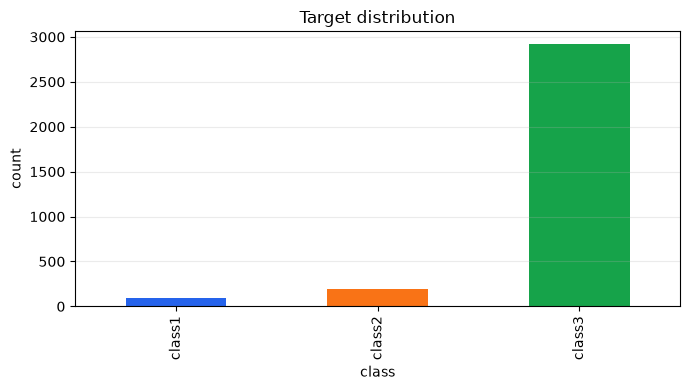

In [3]:
target_counts = train[TARGET_COL].value_counts().sort_index()
target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(train) * 100).round(3)
})
display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Target distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### أثر عدم توازن الفئات


عدم التوازن جعلنا نستخدم <code>StratifiedKFold</code> حتى تبقى نسب الفئات داخل كل fold قريبة من التوزيع الأصلي.

كما جربنا نماذج مع <code>class_weight='balanced'</code> ونماذج بدونها. النتيجة العملية كانت أن بعض النماذج غير الموزونة بقيت قوية، لأن الفئات الصغيرة ليست عشوائية تماماً بل تظهر في مناطق رقمية واضحة.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 4. أنواع الخصائص


قسمنا الأعمدة حسب قيمها: بعض الخصائص ثنائية 0/1، وبعضها مستمر. هذا التقسيم ساعدنا في بناء خصائص عامة لا تعتمد على معنى العمود.

مثلاً: عدد الخصائص الثنائية المفعلة في الصف، تفاعلات بين الأعمدة المستمرة، ومؤشرات للقيم العالية أو المنخفضة. هذه التحويلات مناسبة لأن الأعمدة مجهولة، ولا تفترض أي معنى خارجي.


</div>


In [4]:
binary_features = []
continuous_features = []
for c in feature_cols:
    train_values = set(train[c].dropna().unique())
    test_values = set(test[c].dropna().unique())
    if train_values.issubset({0, 1, 0.0, 1.0}) and test_values.issubset({0, 1, 0.0, 1.0}):
        binary_features.append(c)
    else:
        continuous_features.append(c)

feature_type_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "train_nunique": [train[c].nunique() for c in feature_cols],
    "test_nunique": [test[c].nunique() for c in feature_cols],
    "train_mean": [train[c].mean() for c in feature_cols],
    "test_mean": [test[c].mean() for c in feature_cols],
})
feature_type_df["abs_mean_diff"] = (feature_type_df["train_mean"] - feature_type_df["test_mean"]).abs()

display(feature_type_df.sort_values(["type", "abs_mean_diff"], ascending=[True, False]))
print("Binary:", binary_features)
print("Continuous:", continuous_features)


,feature,type,train_nunique,test_nunique,train_mean,test_mean,abs_mean_diff
17,f18,binary,2,2,0.059375,0.077188,0.017813
11,f12,binary,2,2,0.122813,0.139375,0.016562
6,f7,binary,2,2,0.005000,0.020938,0.015938
12,f13,binary,2,2,0.061875,0.069687,0.007812
7,f8,binary,2,2,0.012188,0.018437,0.006250
20,f21,binary,2,2,0.013437,0.007500,0.005938
4,f5,binary,2,2,0.014687,0.019062,0.004375
14,f15,binary,2,2,0.011250,0.014063,0.002813
2,f3,binary,2,2,0.045000,0.046562,0.001563
5,f6,binary,2,2,0.038750,0.037187,0.001563


Binary: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
Continuous: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### لماذا تناسب الأشجار هذه الداتا؟


وجود خصائص ثنائية كثيرة مع عدد قليل من الخصائص المستمرة يجعل نماذج الأشجار مناسبة جداً. الشجرة تستطيع بناء قواعد من نوع: قيمة مستمرة أعلى من حد معين، ومعها خاصية ثنائية تساوي صفر أو واحد.

هذا يفسر لماذا كانت Decision Tree وBagging وRandom Forest وLightGBM قريبة جداً في النتائج.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 5. مقارنة توزيع التدريب والاختبار


قارننا متوسط كل خاصية بين التدريب والاختبار لنرى هل هناك اختلاف واضح في التوزيع. الفروقات كانت صغيرة نسبياً، لكنها ليست صفراً.

هذا لا يحدد النموذج وحده، لكنه يعطينا فكرة مهمة: بما أن هناك جزء Private من الاختبار، فالأفضل ألا نعتمد على تجربة واحدة أو split واحد فقط.


</div>


,feature,type,train_mean,test_mean,abs_mean_diff
17,f18,binary,0.059375,0.077188,0.017813
11,f12,binary,0.122813,0.139375,0.016562
6,f7,binary,0.005000,0.020938,0.015938
0,f1,continuous,0.516861,0.526824,0.009963
12,f13,binary,0.061875,0.069687,0.007812
13,f14,continuous,0.109880,0.116732,0.006852
7,f8,binary,0.012188,0.018437,0.006250
20,f21,binary,0.013437,0.007500,0.005938
4,f5,binary,0.014687,0.019062,0.004375
8,f9,continuous,0.107968,0.110992,0.003023


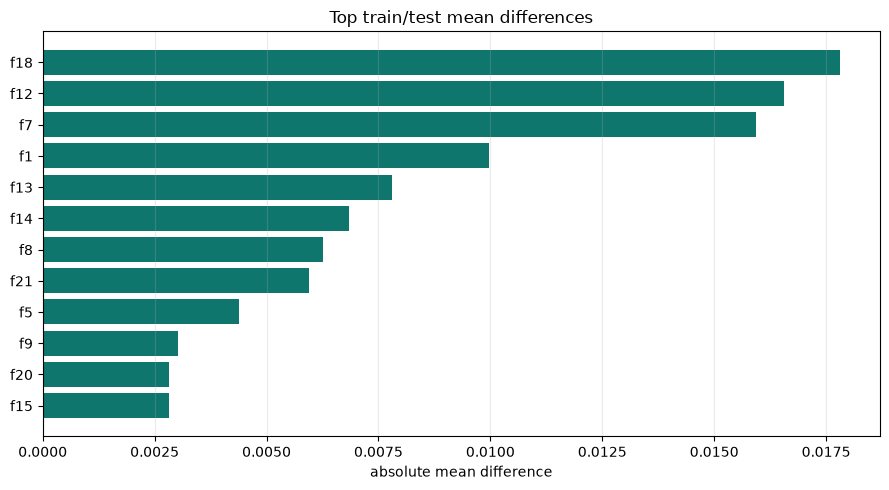

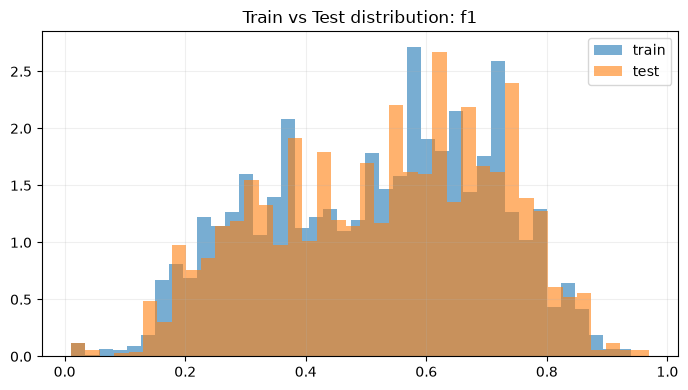

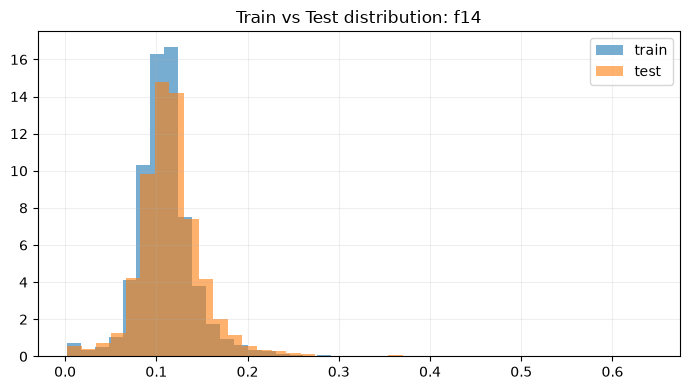

In [5]:
drift_df = feature_type_df.sort_values("abs_mean_diff", ascending=False)
display(drift_df[["feature", "type", "train_mean", "test_mean", "abs_mean_diff"]].head(12))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = drift_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["abs_mean_diff"], color="#0f766e")
ax.set_title("Top train/test mean differences")
ax.set_xlabel("absolute mean difference")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

for c in [x for x in drift_df["feature"].head(6) if x in continuous_features]:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(train[c], bins=40, alpha=0.6, density=True, label="train")
    ax.hist(test[c], bins=40, alpha=0.6, density=True, label="test")
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### أثر اختلاف التوزيع


التوزيع العام متقارب، لذلك التحقق الداخلي مفيد. لكن وجود فروقات صغيرة يعني أن النموذج الأكثر ثباتاً أفضل من نموذج يربح بفارق صغير جداً في تجربة واحدة.

لهذا أضفنا لاحقاً فحصاً عبر أكثر من <code>random_state</code>، وفحصاً للصفوف التدريبية التي تشبه الاختبار أكثر.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 6. أهمية الخصائص


استخدمنا <code>Mutual Information</code> و<code>ANOVA F-score</code> لترتيب الخصائص حسب علاقتها بالهدف.

أقوى الإشارات ظهرت غالباً في <code>f10</code> و<code>f14</code> ثم <code>f9</code> و<code>f2</code>. كما ظهرت خصائص ثنائية مثل <code>f12</code> كعامل مساعد مهم، خصوصاً عندما تتفاعل مع حدود على <code>f10</code>.


</div>


,feature,type,mutual_information,anova_f_score,anova_pvalue
9,f10,continuous,0.281781,991.761826,0.000000e+00
13,f14,continuous,0.137953,331.484714,1.502435e-131
8,f9,continuous,0.108202,283.363477,5.076408e-114
1,f2,continuous,0.092057,117.512854,5.669935e-50
11,f12,binary,0.020573,14.852188,3.798027e-07
12,f13,binary,0.012737,14.289268,6.634724e-07
0,f1,continuous,0.012244,0.572002,5.644521e-01
16,f17,binary,0.009627,1.553742,2.116149e-01
19,f20,continuous,0.009546,3.082477,4.598183e-02
15,f16,binary,0.004152,1.177318,3.082374e-01


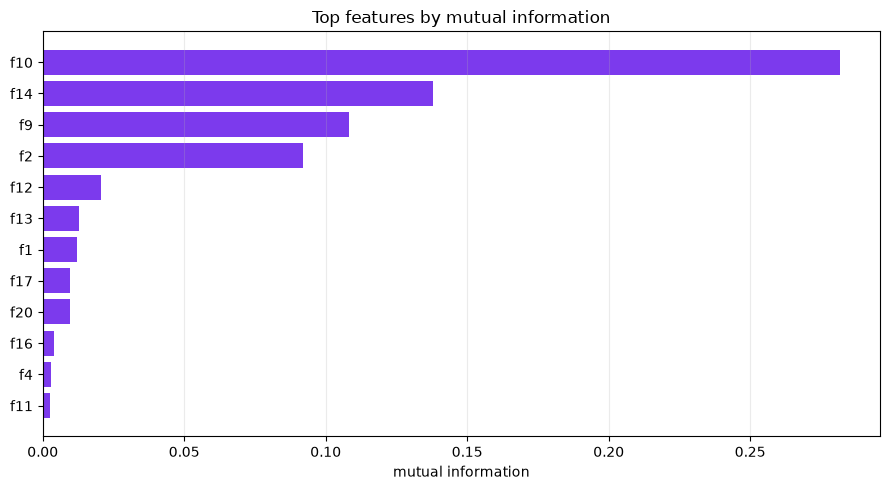

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(train[TARGET_COL])
class_names = list(le.classes_)

mi_scores = mutual_info_classif(train[feature_cols], y_encoded, random_state=RANDOM_STATE)
f_scores, f_pvalues = f_classif(train[feature_cols], y_encoded)
feature_score_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "mutual_information": mi_scores,
    "anova_f_score": f_scores,
    "anova_pvalue": f_pvalues,
}).sort_values("mutual_information", ascending=False)

display(feature_score_df)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = feature_score_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["mutual_information"], color="#7c3aed")
ax.set_title("Top features by mutual information")
ax.set_xlabel("mutual information")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### ماذا يعني ترتيب الخصائص؟


هذا التحليل أعطانا اتجاهين واضحين: أولاً، لا نحتاج هندسة خصائص عشوائية كثيرة. ثانياً، التفاعلات بين <code>f10</code> و<code>f14</code> و<code>f9</code> و<code>f12</code> تستحق التجربة.

لاحقاً أكدت شجرة القرار الخام نفس الفكرة: معظم الفصل بين الفئات يحدث حول حدود رقمية في هذه الأعمدة.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 7. خطة التجارب


بنيناه كمسار تجارب، وليس كقفزة مباشرة إلى نموذج واحد.

<div style="display:grid; grid-template-columns:repeat(auto-fit,minmax(220px,1fr)); gap:12px; margin:14px 0;">
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>1. Baseline</b><br>نماذج بسيطة لمعرفة الحد الأدنى المقبول.</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>2. Trees</b><br>Decision Tree وBagging لفهم القواعد الرقمية.</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>3. Boosting</b><br>LightGBM وXGBoost وGradient Boosting لالتقاط حدود أدق.</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>4. Feature Engineering</b><br>تفاعلات وملخصات عامة من الأعمدة الرقمية والثنائية.</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>5. Ensemble</b><br>دمج احتمالات النماذج عندما تكون أخطاؤها مختلفة.</div>
  <div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;"><b>6. Robustness</b><br>فحص النتيجة عبر seeds وشرائح صعبة وملفات رفع مرشحة.</div>
</div>

الفكرة الأساسية: عندما تكون النتائج متقاربة، لا يكفي أن نقول “هذا أعلى رقم”. نحتاج أن نرى هل الفرق ثابت، وهل النموذج يخطئ في مناطق مفهومة، وهل ملف الرفع الناتج منطقي.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 8. تعريف الـ Pipeline


في هذا القسم نعرّف مكونات التدريب: بناء الخصائص، النماذج، التقييم، الدمج، وحفظ المخرجات.

الخلايا طويلة لأنها تحتوي الكود الكامل القابل لإعادة التشغيل، لكن كل جزء منها له دور محدد. القراءة العلمية المهمة ليست حفظ تفاصيل الكود، بل فهم لماذا أضفنا كل تجربة وكيف قارنّا نتائجها.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.1 الثوابت والاستيرادات


هذه الخلية تجمع أسماء الملفات، إعدادات التحقق، مسار حفظ التقارير، وقوائم النماذج المستخدمة في الـ ensemble.

وضع هذه القيم في مكان واحد يجعل التجربة أسهل للمراجعة: إذا تغير عدد folds أو قائمة النماذج نرى ذلك مباشرة بدل أن يكون مخفياً داخل عدة خلايا.


</div>


In [7]:
"""Clean, reproducible pipeline for the FITE Classification Challenge.

What this script does:
- Reads train_data.csv, test_data.csv, sample_submission.csv.
- Performs train-only feature engineering through a sklearn Transformer.
- Evaluates several models with StratifiedKFold validation.
- Logs all experiments to MLflow when available, otherwise to a CSV fallback.
- Builds a probability ensemble from out-of-fold validation results.
- Saves the official submission.csv plus documented diagnostic submission candidates.

Academic integrity:
- No true_values.csv usage.
- Evaluation is based on train folds only.
- No leaderboard probing.
- No row-specific overrides.
"""

from __future__ import annotations

import json
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")


RANDOM_STATE = 42
N_SPLITS = 5
USE_REFERENCE_ENSEMBLE_CANDIDATE = True
REFERENCE_ENSEMBLE_F1_TOLERANCE = 0.0011
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
OUTPUT_FILE = "submission.csv"
EXPERIMENT_LOG_FILE = "classification_experiment_log.csv"
ARTIFACT_DIR = Path("classification_artifacts")
ROBUST_VALIDATION_SEEDS = [7, 42, 123]
BLENDING_HOLDOUT_SEEDS = [7, 42, 123, 2026, 2027]
STABLE_ENSEMBLE_F1_TOLERANCE = 0.0020
FINAL_ENSEMBLE_MODEL_NAMES = [
    "lightgbm_simple_fe",
    "lightgbm_original",
    "random_forest_original",
    "extra_trees_original",
    "hgb_original",
    "hgb_simple_fe",
    "xgboost_simple_fe",
    "gradient_boosting_fe",
]
REFERENCE_SOFT_VOTING_MODEL_NAMES = [
    "lightgbm_simple_fe",
    "lightgbm_original",
    "random_forest_original",
    "extra_trees_original",
    "hgb_simple_fe",
    "xgboost_simple_fe",
]
REFERENCE_SOFT_VOTING_WEIGHTS = np.array([0.169278, 0.103133, 0.273020, 0.156727, 0.038941, 0.258902], dtype=float)
FINAL_SUBMISSION_POLICY = "conservative_private_safe"


def set_all_seeds(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.2 هندسة خصائص عامة


عرّفنا <code>ClassificationFeatureBuilder</code> لإضافة خصائص عامة: تربيع وجذر للخصائص المستمرة، مؤشرات للقيم الطرفية، وتفاعلات بين الأعمدة المستمرة.

هذه التحويلات لا تعتمد على معنى الأعمدة. هي تحاول فقط إعطاء النماذج معلومات إضافية عن الشكل العددي للصف.


</div>


In [8]:
class ClassificationFeatureBuilder(BaseEstimator, TransformerMixin):
    """Train-only generic feature engineering for anonymized tabular data.

    Since feature meanings are hidden, the transformations are intentionally
    domain-neutral: interactions among continuous features, binary counts, rare
    binary counts, and train-quantile outlier indicators.
    """

    def __init__(self, outlier_quantiles: tuple[float, float] = (0.01, 0.99), rare_threshold: float = 0.02):
        self.outlier_quantiles = outlier_quantiles
        self.rare_threshold = rare_threshold

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)

        q_low, q_high = self.outlier_quantiles
        self.low_quantiles_ = X[self.cont_cols_].quantile(q_low).to_dict()
        self.high_quantiles_ = X[self.cont_cols_].quantile(q_high).to_dict()
        self.rare_binary_cols_ = [col for col in self.binary_cols_ if float(X[col].mean()) < self.rare_threshold]
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()

        eps = 1e-6
        for col in self.cont_cols_:
            out[f"{col}_sq"] = X[col] ** 2
            out[f"{col}_sqrt"] = np.sqrt(np.clip(X[col], 0, None))
            out[f"{col}_below_q01"] = (X[col] < self.low_quantiles_[col]).astype(int)
            out[f"{col}_above_q99"] = (X[col] > self.high_quantiles_[col]).astype(int)

        # Generic pairwise interactions for continuous variables.
        for i, a in enumerate(self.cont_cols_):
            for b in self.cont_cols_[i + 1 :]:
                out[f"{a}_x_{b}"] = X[a] * X[b]
                out[f"{a}_minus_{b}"] = X[a] - X[b]
                out[f"{a}_div_{b}"] = X[a] / (np.abs(X[b]) + eps)

        if self.binary_cols_:
            out["binary_sum"] = X[self.binary_cols_].sum(axis=1)
        else:
            out["binary_sum"] = 0

        if self.rare_binary_cols_:
            out["rare_binary_sum"] = X[self.rare_binary_cols_].sum(axis=1)
        else:
            out["rare_binary_sum"] = 0

        if self.cont_cols_:
            out["continuous_outlier_count"] = 0
            for col in self.cont_cols_:
                out["continuous_outlier_count"] += out[f"{col}_below_q01"] + out[f"{col}_above_q99"]
        else:
            out["continuous_outlier_count"] = 0

        return out.astype(float)


class SimpleAnonymizedFeatureBuilder(BaseEstimator, TransformerMixin):
    """Smaller generic feature set for the anonymized tabular data.

    This transformer is deliberately generic because the features are
    anonymized. It adds row summaries and interactions among the strongest
    continuous variables found during train-only EDA.
    """

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()
        eps = 1e-9

        if self.binary_cols_:
            out["binary_sum"] = X[self.binary_cols_].sum(axis=1)
            out["binary_mean"] = X[self.binary_cols_].mean(axis=1)
        else:
            out["binary_sum"] = 0
            out["binary_mean"] = 0

        if self.cont_cols_:
            out["cont_mean"] = X[self.cont_cols_].mean(axis=1)
            out["cont_std"] = X[self.cont_cols_].std(axis=1)
            out["cont_min"] = X[self.cont_cols_].min(axis=1)
            out["cont_max"] = X[self.cont_cols_].max(axis=1)
            out["cont_range"] = out["cont_max"] - out["cont_min"]
        else:
            out["cont_mean"] = 0
            out["cont_std"] = 0
            out["cont_min"] = 0
            out["cont_max"] = 0
            out["cont_range"] = 0

        def has(*cols: str) -> bool:
            return all(col in out.columns for col in cols)

        if has("f10", "f14"):
            out["f10_div_f14"] = X["f10"] / (X["f14"] + eps)
            out["f10_minus_f14"] = X["f10"] - X["f14"]
            out["f10_mul_f14"] = X["f10"] * X["f14"]
        if has("f10", "f9"):
            out["f10_div_f9"] = X["f10"] / (X["f9"] + eps)
            out["f10_minus_f9"] = X["f10"] - X["f9"]
            out["f10_mul_f9"] = X["f10"] * X["f9"]
        if has("f9", "f14"):
            out["f9_minus_f14"] = X["f9"] - X["f14"]
            out["f9_div_f14"] = X["f9"] / (X["f14"] + eps)
        if has("f2", "f10"):
            out["f2_mul_f10"] = X["f2"] * X["f10"]
            out["f2_div_f10"] = X["f2"] / (X["f10"] + eps)

        out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
        return out.astype(float)


class EDAFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe EDA-driven features for the anonymized tabular data.

    The features are still generic, but they focus on patterns that repeatedly
    appeared useful during train-only analysis: f10/f14/f9/f2 interactions,
    f12 interactions, default-like binary rows, repeated tuples, and continuous
    tail indicators.
    """

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)

        quantiles = [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
        self.cont_quantiles_ = {
            col: X[col].quantile(quantiles).to_dict()
            for col in self.cont_cols_
        }
        if self.binary_cols_:
            self.default_binary_pattern_ = X[self.binary_cols_].mode().iloc[0].astype(int)
        else:
            self.default_binary_pattern_ = pd.Series(dtype=int)

        tuple_counts = X[self.feature_names_in_].apply(lambda row: tuple(row.values.tolist()), axis=1).value_counts()
        self.tuple_count_map_ = tuple_counts.to_dict()
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()
        eps = 1e-9

        if self.binary_cols_:
            binary_values = X[self.binary_cols_].astype(int)
            out["binary_sum"] = binary_values.sum(axis=1)
            out["binary_mean"] = binary_values.mean(axis=1)
            out["default_binary_distance"] = binary_values.ne(self.default_binary_pattern_, axis=1).sum(axis=1)
            out["is_default_binary_pattern"] = (out["default_binary_distance"] == 0).astype(int)
            out["binary_distance_ge_3"] = (out["default_binary_distance"] >= 3).astype(int)
        else:
            out["binary_sum"] = 0
            out["binary_mean"] = 0
            out["default_binary_distance"] = 0
            out["is_default_binary_pattern"] = 0
            out["binary_distance_ge_3"] = 0

        if self.cont_cols_:
            out["cont_mean"] = X[self.cont_cols_].mean(axis=1)
            out["cont_std"] = X[self.cont_cols_].std(axis=1).fillna(0)
            out["cont_range"] = X[self.cont_cols_].max(axis=1) - X[self.cont_cols_].min(axis=1)
            out["continuous_outlier_count"] = 0
            for col in self.cont_cols_:
                q = self.cont_quantiles_[col]
                out[f"{col}_ge_q75"] = (X[col] >= q[0.75]).astype(int)
                out[f"{col}_ge_q90"] = (X[col] >= q[0.90]).astype(int)
                out[f"{col}_le_q10"] = (X[col] <= q[0.10]).astype(int)
                out[f"{col}_tail"] = ((X[col] <= q[0.01]) | (X[col] >= q[0.99])).astype(int)
                out["continuous_outlier_count"] += out[f"{col}_tail"]
        else:
            out["cont_mean"] = 0
            out["cont_std"] = 0
            out["cont_range"] = 0
            out["continuous_outlier_count"] = 0

        def has(*cols: str) -> bool:
            return all(col in X.columns for col in cols)

        if has("f10", "f12"):
            f12_zero = (X["f12"] == 0).astype(int)
            f12_one = (X["f12"] == 1).astype(int)
            out["f10_when_f12_0"] = X["f10"] * f12_zero
            out["f10_when_f12_1"] = X["f10"] * f12_one
            if "f10" in self.cont_quantiles_:
                out["f10_ge_q75_and_f12_0"] = ((X["f10"] >= self.cont_quantiles_["f10"][0.75]) & (X["f12"] == 0)).astype(int)
                out["f10_ge_q90_and_f12_0"] = ((X["f10"] >= self.cont_quantiles_["f10"][0.90]) & (X["f12"] == 0)).astype(int)
        if has("f10", "f14"):
            out["f10_div_f14"] = X["f10"] / (X["f14"] + eps)
            out["f10_minus_f14"] = X["f10"] - X["f14"]
            out["f10_mul_f14"] = X["f10"] * X["f14"]
            if "f10" in self.cont_quantiles_ and "f14" in self.cont_quantiles_:
                out["f10_f14_both_high"] = (
                    (X["f10"] >= self.cont_quantiles_["f10"][0.75])
                    & (X["f14"] >= self.cont_quantiles_["f14"][0.75])
                ).astype(int)
        if has("f10", "f9"):
            out["f10_div_f9"] = X["f10"] / (X["f9"] + eps)
            out["f10_minus_f9"] = X["f10"] - X["f9"]
            out["f10_mul_f9"] = X["f10"] * X["f9"]
        if has("f2", "f10"):
            out["f2_mul_f10"] = X["f2"] * X["f10"]
            out["f2_div_f10"] = X["f2"] / (X["f10"] + eps)

        tuple_keys = X[self.feature_names_in_].apply(lambda row: tuple(row.values.tolist()), axis=1)
        tuple_count = tuple_keys.map(self.tuple_count_map_).fillna(0).astype(float)
        out["repeated_tuple_count"] = tuple_count
        out["repeated_tuple_log1p"] = np.log1p(tuple_count)
        out["is_repeated_tuple"] = (tuple_count > 1).astype(int)

        out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
        return out.astype(float)


class CoreFeatureSelector(BaseEstimator, TransformerMixin):
    """Small, drift-resistant feature subset used as a diagnostic hedge.

    The selected columns came from train-only EDA as consistently high-signal
    anonymized features. It simply restricts the model input to a compact
    raw-feature subset.
    """

    def __init__(self, columns: tuple[str, ...] = ("f10", "f12", "f14", "f9")):
        self.columns = columns

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X)
        missing = [col for col in self.columns if col not in X.columns]
        if missing:
            raise ValueError(f"CoreFeatureSelector missing columns: {missing}")
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X)
        return X.loc[:, list(self.columns)].astype(float)


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.3 خصائص موجهة من التحليل


بعد التحليل الأولي أضفنا نسخاً أخف وأكثر تركيزاً من هندسة الخصائص.

ركزنا على تفاعلات <code>f10</code> مع <code>f14</code> و<code>f9</code> و<code>f12</code>، وعلى ملخصات الصف مثل عدد الخصائص الثنائية المفعلة وعدد القيم الطرفية. هذه الخصائص جاءت من الملاحظة الإحصائية، لا من معنى خارجي للأعمدة.


</div>


In [9]:
class LabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper for classifiers that require numeric class labels."""

    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_
        self.model_ = clone(self.base_estimator)
        self.model_.fit(X, y_encoded)
        return self

    def predict(self, X):
        pred_encoded = self.model_.predict(X).astype(int)
        return self.label_encoder_.inverse_transform(pred_encoded)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def try_import_mlflow():
    try:
        import mlflow
        import mlflow.sklearn

        return mlflow
    except Exception:
        return None


def end_active_mlflow_run(mlflow_module) -> None:
    """Close any active MLflow run before starting a new top-level run."""

    if mlflow_module is not None and mlflow_module.active_run() is not None:
        mlflow_module.end_run()


@dataclass
class ExperimentResult:
    model_name: str
    accuracy_mean: float
    accuracy_std: float
    balanced_accuracy_mean: float
    f1_macro_mean: float
    folds: list[float]


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.4 النماذج التي جربناها


جربنا عائلات مختلفة من النماذج:

- نماذج خطية وKNN كمرجع بسيط.
- Decision Tree وBagging لفهم القواعد الخام.
- Random Forest وExtra Trees لتقليل تذبذب الشجرة الواحدة.
- HistGradientBoosting وGradientBoosting.
- LightGBM وXGBoost عند توفرهما.

أضفنا أيضاً نسختين دفاعيتين: LightGBM بدون class weights، ونموذج صغير يستخدم فقط <code>f10</code>, <code>f12</code>, <code>f14</code>, <code>f9</code>.


</div>


In [10]:
def make_models() -> dict[str, Pipeline]:
    models = {
        "gradient_boosting_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    GradientBoostingClassifier(
                        n_estimators=220,
                        learning_rate=0.045,
                        max_depth=3,
                        min_samples_leaf=4,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "hgb_original": Pipeline(
            [
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=350,
                        learning_rate=0.04,
                        l2_regularization=0.01,
                        random_state=RANDOM_STATE + 10,
                    ),
                ),
            ]
        ),
        "hgb_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=280,
                        learning_rate=0.04,
                        max_leaf_nodes=31,
                        l2_regularization=0.03,
                        random_state=RANDOM_STATE + 1,
                    ),
                ),
            ]
        ),
        "hgb_simple_fe": Pipeline(
            [
                ("features", SimpleAnonymizedFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=350,
                        learning_rate=0.04,
                        l2_regularization=0.01,
                        random_state=RANDOM_STATE + 11,
                    ),
                ),
            ]
        ),
        "random_forest_original": Pipeline(
            [
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=700,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE + 12,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "decision_tree_raw_depth5": Pipeline(
            [
                (
                    "model",
                    DecisionTreeClassifier(
                        max_depth=5,
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 14,
                    ),
                ),
            ]
        ),
        "bagging_tree_original": Pipeline(
            [
                (
                    "model",
                    BaggingClassifier(
                        estimator=DecisionTreeClassifier(
                            min_samples_leaf=2,
                            class_weight="balanced",
                            random_state=RANDOM_STATE + 15,
                        ),
                        n_estimators=120,
                        random_state=RANDOM_STATE + 16,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "random_forest_balanced_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=420,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE + 2,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "hgb_eda_fe": Pipeline(
            [
                ("features", EDAFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=320,
                        learning_rate=0.04,
                        max_leaf_nodes=31,
                        l2_regularization=0.02,
                        random_state=RANDOM_STATE + 17,
                    ),
                ),
            ]
        ),
        "extra_trees_original": Pipeline(
            [
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=900,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 13,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "extra_trees_balanced_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 3,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "logreg_balanced_fe_scaled": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=4000,
                        C=1.0,
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 4,
                    ),
                ),
            ]
        ),
    }

    try:
        from lightgbm import LGBMClassifier

        lgbm_params = dict(
            n_estimators=700,
            learning_rate=0.035,
            max_depth=-1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multiclass",
            class_weight="balanced",
            random_state=RANDOM_STATE + 20,
            n_jobs=-1,
            verbosity=-1,
        )
        lgbm_unweighted_params = {
            **lgbm_params,
            "class_weight": None,
            "random_state": RANDOM_STATE + 22,
        }
        lgbm_core_params = {
            **lgbm_unweighted_params,
            "num_leaves": 15,
            "random_state": RANDOM_STATE + 23,
        }
        models["lightgbm_original"] = Pipeline([("model", LGBMClassifier(**lgbm_params))])
        models["lightgbm_simple_fe"] = Pipeline(
            [("features", SimpleAnonymizedFeatureBuilder()), ("model", LGBMClassifier(**lgbm_params))]
        )
        models["lightgbm_eda_fe"] = Pipeline(
            [("features", EDAFeatureBuilder()), ("model", LGBMClassifier(**lgbm_params))]
        )
        models["lightgbm_unweighted_original"] = Pipeline([("model", LGBMClassifier(**lgbm_unweighted_params))])
        models["lightgbm_core4_unweighted"] = Pipeline(
            [("features", CoreFeatureSelector()), ("model", LGBMClassifier(**lgbm_core_params))]
        )
    except Exception as exc:
        print(f"LightGBM unavailable, skipped: {exc}")

    try:
        from xgboost import XGBClassifier

        xgb_params = dict(
            n_estimators=600,
            learning_rate=0.035,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE + 21,
            n_jobs=-1,
        )
        models["xgboost_simple_fe"] = Pipeline(
            [
                ("features", SimpleAnonymizedFeatureBuilder()),
                ("model", LabelEncodedClassifier(XGBClassifier(**xgb_params))),
            ]
        )
    except Exception as exc:
        print(f"XGBoost unavailable, skipped: {exc}")

    preferred_model_order = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "lightgbm_unweighted_original",
        "lightgbm_core4_unweighted",
        "random_forest_original",
        "decision_tree_raw_depth5",
        "bagging_tree_original",
        "extra_trees_original",
        "lightgbm_eda_fe",
        "hgb_eda_fe",
        "hgb_original",
        "hgb_simple_fe",
        "xgboost_simple_fe",
        "gradient_boosting_fe",
    ]
    models = {name: models[name] for name in preferred_model_order if name in models}
    return models


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.5 تجربة ADASYN و BorderlineSMOTE


جربنا oversampling كفكرة لمعالجة قلة أمثلة <code>class1</code> و<code>class2</code>. استخدمنا ADASYN وBorderlineSMOTE بشكل محافظ، لأن توليد عينات كثيرة حول الحدود قد يزيد الخلط بدل أن يحسنه.

التجربة وضعت للمقارنة فقط. إذا لم ترفع <code>Macro F1</code> بشكل واضح، فهي تبقى نتيجة سلبية مفيدة: جربنا معالجة عدم التوازن ووجدنا أن النماذج الأصلية تكفي أكثر.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.6 تقييم النماذج


نستخدم <code>StratifiedKFold</code> ونحفظ احتمالات OOF لكل نموذج. هذه الاحتمالات مهمة لأنها تعطينا تنبؤاً لكل صف من نموذج لم يتدرب على هذا الصف.

من هذه الاحتمالات نحسب <code>Accuracy</code> و<code>Balanced Accuracy</code> و<code>Macro F1</code>، ثم نستخدمها لاحقاً لبناء الـ ensemble وتحليل الأخطاء.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.7 دمج النماذج


الـ ensemble هنا مبني على احتمالات النماذج، لا على تصويت نهائي فقط. إذا كان نموذج قوي يخطئ في صفوف مختلفة عن نموذج آخر، فالدمج قد يصحح جزءاً من هذه الأخطاء.

<div style="border:1px solid rgba(127,127,127,0.28); border-radius:10px; padding:12px 14px; margin:10px 0; background:rgba(127,127,127,0.06); color:inherit;">
اخترنا الأوزان بناءً على OOF، ثم فحصناها بطرق إضافية مثل holdout داخلي وnested greedy. الهدف أن نميز بين تحسن حقيقي وتحسن صغير ناتج عن اختيار أوزان مناسبة جداً لنفس بيانات التحقق.
</div>


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.9; font-size:16px;">

### دوال التقييم والتجارب التشخيصية

هنا نعرّف الدوال التي تقيس أداء النماذج وتنتج الجداول التحليلية. هذه المرحلة تشمل تدريب النماذج على folds، حساب `OOF predictions`، بناء مصفوفات الالتباس، وتجارب الثبات مثل مقارنة الـ baselines وتجربة موازنة الفئات.

وجود هذه الدوال قبل `main` ضروري لأن `main` يستدعيها بالترتيب أثناء تنفيذ التدريب الكامل.

</div>


In [ ]:
def make_baseline_models() -> dict[str, Pipeline | BaseEstimator]:
    """Simple baseline models used to document the model-selection path.

    These are not automatically used for the final submission. They document
        the model-selection path and provide a fair comparison against simpler
        reference models.
    """

    return {
        "decision_tree_raw_depth5": DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "knn_scaled": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
            ]
        ),
        "decision_tree_balanced": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "bagging_tree": BaggingClassifier(
            estimator=DecisionTreeClassifier(
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=80,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "adaboost_tree": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=100,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        ),
        "logreg_balanced_fe_scaled": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=4000,
                        C=1.0,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }


def evaluate_pipeline_collection(
    models: dict[str, Pipeline | BaseEstimator],
    X: pd.DataFrame,
    y: pd.Series,
    random_state: int,
) -> pd.DataFrame:
    """Evaluate a model collection with StratifiedKFold and return one row per model."""

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    rows = []
    for model_name, pipeline in models.items():
        fold_acc = []
        fold_bal = []
        fold_f1 = []
        for train_idx, valid_idx in cv.split(X, y):
            model = clone(pipeline)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X.iloc[valid_idx])
            fold_acc.append(accuracy_score(y.iloc[valid_idx], pred))
            fold_bal.append(balanced_accuracy_score(y.iloc[valid_idx], pred))
            fold_f1.append(f1_score(y.iloc[valid_idx], pred, average="macro"))

        rows.append(
            {
                "model_name": model_name,
                "random_state": random_state,
                "accuracy_mean": float(np.mean(fold_acc)),
                "accuracy_std": float(np.std(fold_acc)),
                "balanced_accuracy_mean": float(np.mean(fold_bal)),
                "f1_macro_mean": float(np.mean(fold_f1)),
                "f1_macro_std": float(np.std(fold_f1)),
            }
        )
    return pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)


def save_model_oof_confusion_matrices(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
) -> pd.DataFrame:
    """Save one compact confusion-matrix table for every OOF model."""

    rows = []
    labels = list(label_encoder.classes_)
    for model_name, proba in oof_probabilities.items():
        pred_labels = label_encoder.inverse_transform(np.argmax(proba, axis=1))
        cm = confusion_matrix(y, pred_labels, labels=labels)
        for true_idx, true_label in enumerate(labels):
            for pred_idx, pred_label in enumerate(labels):
                rows.append(
                    {
                        "model_name": model_name,
                        "true_label": true_label,
                        "pred_label": pred_label,
                        "count": int(cm[true_idx, pred_idx]),
                    }
                )

    confusion_df = pd.DataFrame(rows)
    confusion_df.to_csv(ARTIFACT_DIR / "model_oof_confusion_matrices.csv", index=False)
    return confusion_df


def run_baseline_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Evaluate simpler baseline models for documentation."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    print("\nBaseline audit:")
    baseline_df = evaluate_pipeline_collection(make_baseline_models(), X, y, RANDOM_STATE)
    baseline_df.to_csv(ARTIFACT_DIR / "baseline_results.csv", index=False)
    print(baseline_df.to_string(index=False))

    raw_tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)
    raw_tree.fit(X, y)
    tree_importance = (
        pd.DataFrame({"feature": X.columns, "importance": raw_tree.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    tree_importance.to_csv(ARTIFACT_DIR / "raw_decision_tree_feature_importance.csv", index=False)
    tree_rules = export_text(raw_tree, feature_names=list(X.columns), max_depth=5)
    (ARTIFACT_DIR / "raw_decision_tree_rules.txt").write_text(tree_rules, encoding="utf-8")

    if mlflow_module is not None:
        for _, row in baseline_df.iterrows():
            end_active_mlflow_run(mlflow_module)
            with mlflow_module.start_run(run_name=f"baseline_{row['model_name']}"):
                mlflow_module.log_param("model_name", row["model_name"])
                mlflow_module.log_param("purpose", "baseline_audit")
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_param("random_state", int(row["random_state"]))
                mlflow_module.log_metric("accuracy_mean", float(row["accuracy_mean"]))
                mlflow_module.log_metric("accuracy_std", float(row["accuracy_std"]))
                mlflow_module.log_metric("balanced_accuracy_mean", float(row["balanced_accuracy_mean"]))
                mlflow_module.log_metric("f1_macro_mean", float(row["f1_macro_mean"]))
                mlflow_module.log_metric("f1_macro_std", float(row["f1_macro_std"]))
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="raw_decision_tree_diagnostics"):
            mlflow_module.log_param("purpose", "raw_tree_interpretability")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "raw_decision_tree_feature_importance.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "raw_decision_tree_rules.txt"), artifact_path="classification_artifacts")

    return baseline_df


def run_robust_validation_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Check whether strong models stay strong across several CV seeds."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    all_models = make_models()
    selected_names = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "lightgbm_unweighted_original",
        "lightgbm_core4_unweighted",
        "lightgbm_eda_fe",
        "gradient_boosting_fe",
        "hgb_simple_fe",
        "hgb_eda_fe",
        "random_forest_original",
        "decision_tree_raw_depth5",
        "bagging_tree_original",
    ]
    selected_models = {name: all_models[name] for name in selected_names if name in all_models}

    print("\nRobust validation audit across multiple CV seeds:")
    robust_rows = []
    for seed in ROBUST_VALIDATION_SEEDS:
        seed_df = evaluate_pipeline_collection(selected_models, X, y, seed)
        robust_rows.append(seed_df)
    robust_df = pd.concat(robust_rows, ignore_index=True)
    robust_df.to_csv(ARTIFACT_DIR / "robust_validation_by_seed.csv", index=False)

    summary_df = (
        robust_df.groupby("model_name")
        .agg(
            f1_macro_mean_over_seeds=("f1_macro_mean", "mean"),
            f1_macro_std_over_seeds=("f1_macro_mean", "std"),
            f1_macro_min_over_seeds=("f1_macro_mean", "min"),
            accuracy_mean_over_seeds=("accuracy_mean", "mean"),
            balanced_accuracy_mean_over_seeds=("balanced_accuracy_mean", "mean"),
        )
        .reset_index()
        .sort_values("f1_macro_mean_over_seeds", ascending=False)
    )
    summary_df.to_csv(ARTIFACT_DIR / "robust_validation_summary.csv", index=False)
    print(summary_df.to_string(index=False))

    if mlflow_module is not None:
        for _, row in summary_df.iterrows():
            end_active_mlflow_run(mlflow_module)
            with mlflow_module.start_run(run_name=f"robust_{row['model_name']}"):
                mlflow_module.log_param("model_name", row["model_name"])
                mlflow_module.log_param("purpose", "robust_validation_multi_seed")
                mlflow_module.log_param("seeds", ",".join(map(str, ROBUST_VALIDATION_SEEDS)))
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_metric("f1_macro_mean_over_seeds", float(row["f1_macro_mean_over_seeds"]))
                mlflow_module.log_metric("f1_macro_std_over_seeds", float(row["f1_macro_std_over_seeds"]))
                mlflow_module.log_metric("f1_macro_min_over_seeds", float(row["f1_macro_min_over_seeds"]))
                mlflow_module.log_metric("accuracy_mean_over_seeds", float(row["accuracy_mean_over_seeds"]))
                mlflow_module.log_metric(
                    "balanced_accuracy_mean_over_seeds",
                    float(row["balanced_accuracy_mean_over_seeds"]),
                )

    return summary_df


def run_hard_sampling_audit(
    X: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    mlflow_module=None,
) -> pd.DataFrame:
    """Optional fold-safe ADASYN/BorderlineSMOTE audit.

    The sampler is fitted only on each training fold, never before splitting.
    This keeps the experiment leakage-safe. The audit is diagnostic only and
    does not change the final submission policy.
    """

    ARTIFACT_DIR.mkdir(exist_ok=True)
    try:
        from imblearn.over_sampling import ADASYN, BorderlineSMOTE
        from lightgbm import LGBMClassifier
    except Exception as exc:
        skipped = pd.DataFrame(
            [
                {
                    "experiment": "hard_sampling_audit",
                    "status": "skipped",
                    "reason": f"optional dependency unavailable: {exc}",
                }
            ]
        )
        skipped.to_csv(ARTIFACT_DIR / "hard_sampling_adasyn_results.csv", index=False)
        print("\nHard sampling audit skipped:", exc)
        return skipped

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    labels = list(label_encoder.classes_)
    binary_cols = []
    for col in X.columns:
        vals = set(pd.Series(X[col]).dropna().unique())
        if vals.issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)

    def conservative_strategy(y_values):
        counts = pd.Series(y_values).value_counts()
        majority_count = int(counts.max())
        target_count = int(np.ceil(0.25 * majority_count))
        return {cls: target_count for cls, count in counts.items() if count < target_count}

    samplers = {
        "borderline_smote_raw_lgbm": BorderlineSMOTE(
            sampling_strategy=conservative_strategy,
            k_neighbors=5,
            m_neighbors=10,
            kind="borderline-1",
            random_state=RANDOM_STATE,
        ),
        "adasyn_raw_lgbm": ADASYN(
            sampling_strategy=conservative_strategy,
            n_neighbors=5,
            random_state=RANDOM_STATE,
        ),
    }
    base_params = dict(
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multiclass",
        random_state=RANDOM_STATE + 31,
        n_jobs=-1,
        verbosity=-1,
    )

    rows = []
    confusion_rows = []
    for experiment_name, sampler in samplers.items():
        oof_pred = np.empty(len(y), dtype=object)
        fold_rows = []
        for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            X_train = X.iloc[train_idx].reset_index(drop=True)
            y_train = y.iloc[train_idx].reset_index(drop=True)
            X_valid = X.iloc[valid_idx]
            y_valid = y.iloc[valid_idx]

            sampler_fold = clone(sampler)
            try:
                X_resampled, y_resampled = sampler_fold.fit_resample(X_train, y_train)
                X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
                for col in binary_cols:
                    X_resampled[col] = (X_resampled[col] >= 0.5).astype(int)
                y_resampled = pd.Series(y_resampled)
                status = "resampled"
            except Exception as exc:
                X_resampled = X_train
                y_resampled = y_train
                status = f"fallback_original: {exc}"

            model = LGBMClassifier(**base_params)
            model.fit(X_resampled, y_resampled)
            pred = model.predict(X_valid)
            oof_pred[valid_idx] = pred
            fold_rows.append(
                {
                    "experiment": experiment_name,
                    "fold": fold,
                    "status": status,
                    "resampled_train_size": int(len(y_resampled)),
                    "accuracy": float(accuracy_score(y_valid, pred)),
                    "balanced_accuracy": float(balanced_accuracy_score(y_valid, pred)),
                    "macro_f1": float(f1_score(y_valid, pred, average="macro")),
                }
            )

        fold_df = pd.DataFrame(fold_rows)
        cm = confusion_matrix(y, oof_pred, labels=labels)
        for true_idx, true_label in enumerate(labels):
            for pred_idx, pred_label in enumerate(labels):
                confusion_rows.append(
                    {
                        "experiment": experiment_name,
                        "true_label": true_label,
                        "pred_label": pred_label,
                        "count": int(cm[true_idx, pred_idx]),
                    }
                )

        rows.append(
            {
                "experiment": experiment_name,
                "status": "completed",
                "accuracy_mean": float(fold_df["accuracy"].mean()),
                "balanced_accuracy_mean": float(fold_df["balanced_accuracy"].mean()),
                "macro_f1_mean": float(fold_df["macro_f1"].mean()),
                "macro_f1_std": float(fold_df["macro_f1"].std()),
                "mean_resampled_train_size": float(fold_df["resampled_train_size"].mean()),
            }
        )

    result_df = pd.DataFrame(rows).sort_values("macro_f1_mean", ascending=False)
    confusion_df = pd.DataFrame(confusion_rows)
    result_df.to_csv(ARTIFACT_DIR / "hard_sampling_adasyn_results.csv", index=False)
    confusion_df.to_csv(ARTIFACT_DIR / "hard_sampling_adasyn_confusion_matrices.csv", index=False)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="hard_sampling_adasyn_audit"):
            mlflow_module.log_param("purpose", "fold_safe_optional_sampler_audit")
            mlflow_module.log_param("sampling_strategy", "minority classes up to 25 percent of fold majority")
            for _, row in result_df.iterrows():
                prefix = row["experiment"]
                mlflow_module.log_metric(f"{prefix}_macro_f1_mean", float(row["macro_f1_mean"]))
                mlflow_module.log_metric(f"{prefix}_balanced_accuracy_mean", float(row["balanced_accuracy_mean"]))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "hard_sampling_adasyn_results.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(
                str(ARTIFACT_DIR / "hard_sampling_adasyn_confusion_matrices.csv"),
                artifact_path="classification_artifacts",
            )

    print("\nHard sampling ADASYN/BorderlineSMOTE audit:")
    print(result_df.to_string(index=False))
    return result_df


def summarize_feature_duplicates(X: pd.DataFrame, y: pd.Series) -> dict:
    """Summarize repeated feature rows from the available feature table."""

    audit_df = X.copy()
    audit_df["target"] = y.values
    feature_cols = list(X.columns)
    group_sizes = audit_df.groupby(feature_cols, dropna=False).size().rename("group_size")
    target_counts = audit_df.groupby(feature_cols, dropna=False)["target"].nunique().rename("n_targets")
    duplicate_summary = pd.concat([group_sizes, target_counts], axis=1).reset_index()

    duplicate_groups = duplicate_summary[duplicate_summary["group_size"] > 1]
    conflicting_groups = duplicate_groups[duplicate_groups["n_targets"] > 1]
    exact_feature_duplicate_rows = int(X.duplicated().sum())
    exact_feature_target_duplicate_rows = int(audit_df.duplicated(subset=feature_cols + ["target"]).sum())

    return {
        "rows": int(len(X)),
        "unique_feature_rows": int(len(duplicate_summary)),
        "exact_feature_duplicate_rows": exact_feature_duplicate_rows,
        "duplicate_feature_groups": int(len(duplicate_groups)),
        "conflicting_duplicate_feature_groups": int(len(conflicting_groups)),
        "exact_feature_target_duplicate_rows": exact_feature_target_duplicate_rows,
    }


def build_duplicate_policy_dataset(X: pd.DataFrame, y: pd.Series, policy: str) -> tuple[pd.DataFrame, pd.Series]:
    """Return a train-only dataset variant for duplicate-policy ablation."""

    if policy == "keep_all_rows":
        return X.copy(), y.copy()

    work = X.copy()
    work["target"] = y.values
    feature_cols = list(X.columns)

    if policy == "drop_feature_duplicates_keep_first":
        reduced = work.drop_duplicates(subset=feature_cols, keep="first").reset_index(drop=True)
    elif policy == "drop_exact_feature_target_duplicates_keep_first":
        reduced = work.drop_duplicates(subset=feature_cols + ["target"], keep="first").reset_index(drop=True)
    elif policy == "feature_duplicates_majority_target":
        reduced = (
            work.groupby(feature_cols, dropna=False)["target"]
            .agg(lambda values: values.value_counts().index[0])
            .reset_index()
        )
    else:
        raise ValueError(f"Unknown duplicate policy: {policy}")

    return reduced[feature_cols].reset_index(drop=True), reduced["target"].reset_index(drop=True)


def run_duplicate_policy_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Compare duplicate handling strategies with the same CV protocol.

    This is intentionally diagnostic. It does not change the final submission
    unless the evidence clearly supports a safer policy.
    """

    ARTIFACT_DIR.mkdir(exist_ok=True)
    duplicate_stats = summarize_feature_duplicates(X, y)
    pd.DataFrame([duplicate_stats]).to_csv(ARTIFACT_DIR / "duplicate_summary.csv", index=False)

    selected_models: dict[str, Pipeline | BaseEstimator] = {
        "decision_tree_raw_depth5": DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "decision_tree_balanced_depth8": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE + 1,
        ),
        "extra_trees_fast": ExtraTreesClassifier(
            n_estimators=180,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE + 2,
            n_jobs=-1,
        ),
        "hgb_fast": HistGradientBoostingClassifier(
            max_iter=140,
            learning_rate=0.05,
            l2_regularization=0.02,
            random_state=RANDOM_STATE + 3,
        ),
    }
    policies = [
        "keep_all_rows",
        "drop_exact_feature_target_duplicates_keep_first",
        "drop_feature_duplicates_keep_first",
        "feature_duplicates_majority_target",
    ]

    rows = []
    print("\nDuplicate summary:")
    print(pd.DataFrame([duplicate_stats]).to_string(index=False))
    print("\nDuplicate policy audit:")

    for policy in policies:
        X_policy, y_policy = build_duplicate_policy_dataset(X, y, policy)
        policy_results = evaluate_pipeline_collection(selected_models, X_policy, y_policy, RANDOM_STATE)
        policy_results.insert(0, "duplicate_policy", policy)
        policy_results.insert(1, "n_rows_after_policy", len(X_policy))
        rows.append(policy_results)
        print(f"\nPolicy: {policy} | rows: {len(X_policy)}")
        print(policy_results[["model_name", "f1_macro_mean", "balanced_accuracy_mean", "accuracy_mean"]].to_string(index=False))

    audit_df = pd.concat(rows, ignore_index=True)
    audit_df.to_csv(ARTIFACT_DIR / "duplicate_policy_audit.csv", index=False)

    summary_df = (
        audit_df.groupby("duplicate_policy")
        .agg(
            best_f1_macro=("f1_macro_mean", "max"),
            mean_f1_macro=("f1_macro_mean", "mean"),
            best_balanced_accuracy=("balanced_accuracy_mean", "max"),
            rows_after_policy=("n_rows_after_policy", "first"),
        )
        .reset_index()
        .sort_values("best_f1_macro", ascending=False)
    )
    summary_df.to_csv(ARTIFACT_DIR / "duplicate_policy_summary.csv", index=False)
    print("\nDuplicate policy summary:")
    print(summary_df.to_string(index=False))

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="duplicate_policy_audit"):
            mlflow_module.log_param("purpose", "duplicate_handling_ablation")
            mlflow_module.log_param("policies", ",".join(policies))
            for key, value in duplicate_stats.items():
                mlflow_module.log_metric(key, float(value))
            for _, row in summary_df.iterrows():
                safe_policy = row["duplicate_policy"]
                mlflow_module.log_metric(f"{safe_policy}_best_f1_macro", float(row["best_f1_macro"]))
                mlflow_module.log_metric(f"{safe_policy}_mean_f1_macro", float(row["mean_f1_macro"]))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "duplicate_summary.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "duplicate_policy_audit.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "duplicate_policy_summary.csv"), artifact_path="classification_artifacts")

    return audit_df


def run_adversarial_validation(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    mlflow_module=None,
) -> pd.DataFrame:
    """Check whether train and test feature distributions are easy to separate."""

    X_adv = pd.concat([X_train, X_test], axis=0, ignore_index=True)
    y_adv = pd.Series([0] * len(X_train) + [1] * len(X_test))
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_adv), dtype=float)
    for train_idx, valid_idx in cv.split(X_adv, y_adv):
        model = RandomForestClassifier(
            n_estimators=250,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_adv.iloc[train_idx], y_adv.iloc[train_idx])
        oof[valid_idx] = model.predict_proba(X_adv.iloc[valid_idx])[:, 1]

    auc = roc_auc_score(y_adv, oof)
    rows = []
    for feature in X_train.columns:
        rows.append(
            {
                "feature": feature,
                "train_mean": float(X_train[feature].mean()),
                "test_mean": float(X_test[feature].mean()),
                "abs_mean_diff": float(abs(X_train[feature].mean() - X_test[feature].mean())),
            }
        )
    drift_df = pd.DataFrame(rows).sort_values("abs_mean_diff", ascending=False)
    drift_df["adversarial_auc"] = float(auc)
    drift_df.to_csv(ARTIFACT_DIR / "adversarial_validation.csv", index=False)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="adversarial_validation"):
            mlflow_module.log_param("purpose", "train_test_distribution_check")
            mlflow_module.log_metric("adversarial_auc", float(auc))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "adversarial_validation.csv"), artifact_path="classification_artifacts")

    print("\nAdversarial validation AUC:", round(float(auc), 6))
    print(drift_df.head(12).to_string(index=False))
    return drift_df


def compute_adversarial_train_scores(X_train: pd.DataFrame, X_test: pd.DataFrame) -> tuple[float, np.ndarray]:
    """Return train-vs-test AUC and OOF test-likeness scores for train rows."""

    X_adv = pd.concat([X_train, X_test], axis=0, ignore_index=True)
    y_adv = pd.Series([0] * len(X_train) + [1] * len(X_test))
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_adv), dtype=float)
    for train_idx, valid_idx in cv.split(X_adv, y_adv):
        model = RandomForestClassifier(
            n_estimators=250,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_adv.iloc[train_idx], y_adv.iloc[train_idx])
        oof[valid_idx] = model.predict_proba(X_adv.iloc[valid_idx])[:, 1]

    return float(roc_auc_score(y_adv, oof)), oof[: len(X_train)]


def run_test_like_slice_audit(
    X: pd.DataFrame,
    X_test: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    mlflow_module=None,
) -> pd.DataFrame:
    """Evaluate each OOF model on train rows that look most similar to test rows."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    auc, train_scores = compute_adversarial_train_scores(X, X_test)
    q_low = float(np.quantile(train_scores, 1 / 3))
    q_high = float(np.quantile(train_scores, 2 / 3))
    masks = {
        "all_train": np.ones(len(y), dtype=bool),
        "least_test_like_third": train_scores <= q_low,
        "middle_test_like_third": (train_scores > q_low) & (train_scores < q_high),
        "most_test_like_third": train_scores >= q_high,
    }
    y_enc = label_encoder.transform(y)
    rows = []
    for model_name, proba in oof_probabilities.items():
        pred = np.argmax(proba, axis=1)
        for slice_name, mask in masks.items():
            rows.append(
                {
                    "model_name": model_name,
                    "slice": slice_name,
                    "n_rows": int(mask.sum()),
                    "class1_rows": int((y[mask] == "class1").sum()),
                    "class2_rows": int((y[mask] == "class2").sum()),
                    "class3_rows": int((y[mask] == "class3").sum()),
                    "accuracy": float(accuracy_score(y_enc[mask], pred[mask])),
                    "macro_f1": float(f1_score(y_enc[mask], pred[mask], average="macro")),
                    "balanced_accuracy": float(balanced_accuracy_score(y_enc[mask], pred[mask])),
                    "adversarial_auc": auc,
                }
            )

    slice_df = pd.DataFrame(rows).sort_values(["slice", "macro_f1"], ascending=[True, False])
    slice_df.to_csv(ARTIFACT_DIR / "test_like_slice_audit.csv", index=False)
    pd.DataFrame({"ID": np.arange(len(train_scores)), "test_likeness": train_scores}).to_csv(
        ARTIFACT_DIR / "adversarial_train_scores.csv",
        index=False,
    )
    summary_df = (
        slice_df[slice_df["slice"] == "most_test_like_third"]
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )
    summary_df.to_csv(ARTIFACT_DIR / "test_like_slice_summary.csv", index=False)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="test_like_slice_audit"):
            mlflow_module.log_param("purpose", "private_leaderboard_robustness_check")
            mlflow_module.log_metric("adversarial_auc", auc)
            for _, row in summary_df.head(8).iterrows():
                safe_name = row["model_name"]
                mlflow_module.log_metric(f"{safe_name}_most_test_like_macro_f1", float(row["macro_f1"]))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "test_like_slice_audit.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "test_like_slice_summary.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "adversarial_train_scores.csv"), artifact_path="classification_artifacts")

    print("\nTest-like slice audit:")
    print("Adversarial train-vs-test AUC:", round(auc, 6))
    print(summary_df[["model_name", "n_rows", "macro_f1", "accuracy", "balanced_accuracy"]].head(12).to_string(index=False))
    return slice_df


def evaluate_models(X: pd.DataFrame, y: pd.Series, label_encoder: LabelEncoder, mlflow_module=None):
    models = make_models()
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    class_labels = label_encoder.classes_
    n_classes = len(class_labels)

    results: list[ExperimentResult] = []
    oof_probabilities: dict[str, np.ndarray] = {}

    if mlflow_module is not None:
        # MLflow 3 discourages the legacy filesystem tracking backend, so we use
        # a local SQLite backend that is reproducible and easy to submit/share.
        mlflow_module.set_tracking_uri("sqlite:///mlflow.db")
        mlflow_module.set_experiment("FITE_Classification_Challenge")

    for model_name, pipeline in models.items():
        fold_acc = []
        fold_bal = []
        fold_f1 = []
        oof_proba = np.zeros((len(X), n_classes), dtype=float)

        for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            model = clone(pipeline)
            model.fit(X_train, y_train)
            proba = model.predict_proba(X_valid)
            pred = model.classes_[np.argmax(proba, axis=1)]

            # Align probabilities in case class order changes, though it should not.
            aligned = np.zeros((len(valid_idx), n_classes), dtype=float)
            for src_idx, cls in enumerate(model.classes_):
                dst_idx = np.where(class_labels == cls)[0][0]
                aligned[:, dst_idx] = proba[:, src_idx]
            oof_proba[valid_idx] = aligned

            acc = accuracy_score(y_valid, pred)
            bal = balanced_accuracy_score(y_valid, pred)
            f1 = f1_score(y_valid, pred, average="macro")
            fold_acc.append(acc)
            fold_bal.append(bal)
            fold_f1.append(f1)
            print(f"{model_name:28s} fold {fold}: acc={acc:.5f} bal_acc={bal:.5f} f1_macro={f1:.5f}")

        result = ExperimentResult(
            model_name=model_name,
            accuracy_mean=float(np.mean(fold_acc)),
            accuracy_std=float(np.std(fold_acc)),
            balanced_accuracy_mean=float(np.mean(fold_bal)),
            f1_macro_mean=float(np.mean(fold_f1)),
            folds=[float(x) for x in fold_acc],
        )
        results.append(result)
        oof_probabilities[model_name] = oof_proba

        if mlflow_module is not None:
            end_active_mlflow_run(mlflow_module)
            with mlflow_module.start_run(run_name=model_name):
                mlflow_module.log_param("model_name", model_name)
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_param("random_state", RANDOM_STATE)
                mlflow_module.log_metric("accuracy_mean", result.accuracy_mean)
                mlflow_module.log_metric("accuracy_std", result.accuracy_std)
                mlflow_module.log_metric("balanced_accuracy_mean", result.balanced_accuracy_mean)
                mlflow_module.log_metric("f1_macro_mean", result.f1_macro_mean)
                mlflow_module.log_dict({"accuracy_folds": result.folds}, "fold_metrics.json")

    confusion_df = save_model_oof_confusion_matrices(y, label_encoder, oof_probabilities)
    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="model_oof_confusion_matrices"):
            mlflow_module.log_param("purpose", "per_model_oof_error_analysis")
            mlflow_module.log_artifact(
                str(ARTIFACT_DIR / "model_oof_confusion_matrices.csv"),
                artifact_path="classification_artifacts",
            )

    print("\nSaved per-model OOF confusion matrices:")
    print(confusion_df.head(18).to_string(index=False))

    return models, results, oof_probabilities


In [11]:
def optimize_ensemble_weights(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    random_state: int = RANDOM_STATE,
):
    model_names = list(oof_probabilities)
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)

    rng = np.random.default_rng(random_state)
    best_f1 = -1.0
    best_acc = -1.0
    best_weights = None
    best_pred = None
    candidate_records = []

    # Include single-model weights and random convex blends.
    candidates = []
    for i in range(len(model_names)):
        w = np.zeros(len(model_names))
        w[i] = 1.0
        candidates.append(w)
    candidate_labels = [f"single_{name}" for name in model_names]

    if USE_REFERENCE_ENSEMBLE_CANDIDATE:
        # Reference soft-voting candidate built from fold-level probability
        # blending over diverse models.
        reference_names = REFERENCE_SOFT_VOTING_MODEL_NAMES
        reference_weights = REFERENCE_SOFT_VOTING_WEIGHTS
        if all(name in model_names for name in reference_names):
            w = np.zeros(len(model_names), dtype=float)
            for name, weight in zip(reference_names, reference_weights):
                w[model_names.index(name)] = weight
            w = w / w.sum()
            candidates.append(w)
            candidate_labels.append("reference_soft_voting_weights")

    for _ in range(6000):
        candidates.append(rng.dirichlet(np.ones(len(model_names))))
        candidate_labels.append("random_dirichlet")

    best_label = None
    for weights, label in zip(candidates, candidate_labels):
        proba = np.tensordot(weights, stack, axes=(0, 0))
        pred_enc = np.argmax(proba, axis=1)
        acc = accuracy_score(y_enc, pred_enc)
        f1 = f1_score(y_enc, pred_enc, average="macro")
        candidate_records.append(
            {
                "label": label,
                "accuracy": float(acc),
                "f1_macro": float(f1),
                "weights": weights,
                "pred_encoded": pred_enc,
            }
        )
        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_acc = float(acc)
            best_f1 = float(f1)
            best_weights = weights
            best_pred = pred_enc
            best_label = label

    reference_record = next(
        (record for record in candidate_records if record["label"] == "reference_soft_voting_weights"),
        None,
    )
    if reference_record is not None and (best_f1 - reference_record["f1_macro"]) <= REFERENCE_ENSEMBLE_F1_TOLERANCE:
        best_acc = reference_record["accuracy"]
        best_f1 = reference_record["f1_macro"]
        best_weights = reference_record["weights"]
        best_pred = reference_record["pred_encoded"]
        best_label = reference_record["label"]

    return {
        "model_names": model_names,
        "weights": best_weights,
        "accuracy": best_acc,
        "f1_macro": best_f1,
        "pred_encoded": best_pred,
        "weight_strategy": best_label,
        "candidate_summary": [
            {k: v for k, v in record.items() if k not in ["weights", "pred_encoded"]}
            for record in candidate_records
            if record["label"] != "random_dirichlet"
        ],
    }


def select_final_ensemble_probabilities(oof_probabilities: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    """Use conservative final models while keeping all models for analysis."""

    selected = {name: oof_probabilities[name] for name in FINAL_ENSEMBLE_MODEL_NAMES if name in oof_probabilities}
    if len(selected) < 3:
        raise RuntimeError("Not enough conservative final models are available for the final ensemble.")
    return selected


def build_reference_soft_voting_info(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
) -> dict | None:
    """Build the team reference probability-weighted ensemble as a reproducible candidate."""

    missing = [name for name in REFERENCE_SOFT_VOTING_MODEL_NAMES if name not in oof_probabilities]
    if missing:
        print("\nReference soft-voting candidate skipped; missing models:", ", ".join(missing))
        return None

    weights = REFERENCE_SOFT_VOTING_WEIGHTS.astype(float)
    weights = weights / weights.sum()
    stack = np.stack([oof_probabilities[name] for name in REFERENCE_SOFT_VOTING_MODEL_NAMES], axis=0)
    blended = np.tensordot(weights, stack, axes=(0, 0))
    pred_encoded = np.argmax(blended, axis=1)
    y_encoded = label_encoder.transform(y)
    return {
        "model_names": list(REFERENCE_SOFT_VOTING_MODEL_NAMES),
        "weights": weights,
        "accuracy": float(accuracy_score(y_encoded, pred_encoded)),
        "f1_macro": float(f1_score(y_encoded, pred_encoded, average="macro")),
        "pred_encoded": pred_encoded,
        "weight_strategy": "reference_soft_voting_candidate",
        "candidate_summary": [],
    }


def save_reference_soft_voting_candidate(
    models: dict[str, Pipeline],
    X: pd.DataFrame,
    y: pd.Series,
    X_test: pd.DataFrame,
    test: pd.DataFrame,
    sample: pd.DataFrame,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    mlflow_module=None,
) -> dict | None:
    """Save the teammate-style soft-voting candidate without overriding submission.csv."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    reference_info = build_reference_soft_voting_info(y, label_encoder, oof_probabilities)
    if reference_info is None:
        return None

    test_proba, _ = fit_final_and_predict(models, X, y, X_test, reference_info)
    pred_labels = label_encoder.inverse_transform(np.argmax(test_proba, axis=1))
    reference_submission = pd.DataFrame({"ID": test["ID"], "target": pred_labels})
    reference_submission = reference_submission.set_index("ID").reindex(sample["ID"]).reset_index()
    reference_path = ARTIFACT_DIR / "submission_reference_soft_voting_candidate.csv"
    reference_submission.to_csv(reference_path, index=False)

    reference_distribution = reference_submission["target"].value_counts().sort_index()
    reference_distribution.to_csv(ARTIFACT_DIR / "reference_soft_voting_distribution.csv")

    info_path = ARTIFACT_DIR / "reference_soft_voting_info.json"
    with open(info_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "model_names": reference_info["model_names"],
                "weights": {
                    name: float(weight)
                    for name, weight in zip(reference_info["model_names"], reference_info["weights"])
                },
                "oof_accuracy": float(reference_info["accuracy"]),
                "oof_f1_macro": float(reference_info["f1_macro"]),
                "weight_strategy": reference_info["weight_strategy"],
                "note": "Reproducible team reference candidate generated from fold-level CV probability blending.",
            },
            f,
            indent=2,
        )

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="reference_soft_voting_candidate"):
            mlflow_module.log_param("purpose", "team_reference_submission_candidate")
            mlflow_module.log_param("model_names", ",".join(reference_info["model_names"]))
            for name, weight in zip(reference_info["model_names"], reference_info["weights"]):
                mlflow_module.log_param(f"weight_{name}", float(weight))
            mlflow_module.log_metric("oof_accuracy", float(reference_info["accuracy"]))
            mlflow_module.log_metric("oof_f1_macro", float(reference_info["f1_macro"]))
            mlflow_module.log_artifact(str(reference_path), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(info_path), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(
                str(ARTIFACT_DIR / "reference_soft_voting_distribution.csv"),
                artifact_path="classification_artifacts",
            )

    print("\nReference soft-voting candidate:")
    print("OOF accuracy:", round(float(reference_info["accuracy"]), 6))
    print("OOF macro F1:", round(float(reference_info["f1_macro"]), 6))
    print("Saved candidate submission:", reference_path)
    print("Candidate target distribution:")
    print(reference_distribution.to_string())
    return reference_info


def greedy_select_ensemble_weights(
    oof_probabilities: dict[str, np.ndarray],
    y_encoded: np.ndarray,
    row_idx: np.ndarray,
    n_rounds: int = 25,
) -> dict[str, float]:
    """Greedy ensemble selection with replacement on a selected row subset."""

    model_names = list(oof_probabilities)
    selected: list[str] = []
    current = np.zeros((len(row_idx), len(np.unique(y_encoded))), dtype=float)
    best_first = max(
        model_names,
        key=lambda name: f1_score(y_encoded[row_idx], np.argmax(oof_probabilities[name][row_idx], axis=1), average="macro"),
    )
    selected.append(best_first)
    current += oof_probabilities[best_first][row_idx]

    for _ in range(n_rounds - 1):
        current_score = f1_score(y_encoded[row_idx], np.argmax(current / len(selected), axis=1), average="macro")
        trial_scores = []
        for name in model_names:
            trial_proba = (current + oof_probabilities[name][row_idx]) / (len(selected) + 1)
            trial_score = f1_score(y_encoded[row_idx], np.argmax(trial_proba, axis=1), average="macro")
            trial_scores.append((trial_score, name))
        best_score, best_name = max(trial_scores, key=lambda item: item[0])
        if best_score < current_score - 1e-12:
            break
        selected.append(best_name)
        current += oof_probabilities[best_name][row_idx]

    counts = pd.Series(selected).value_counts(normalize=True)
    return {name: float(counts.get(name, 0.0)) for name in model_names if counts.get(name, 0.0) > 0}


def blend_with_weight_dict(oof_probabilities: dict[str, np.ndarray], weights: dict[str, float], row_idx=None) -> np.ndarray:
    """Blend probability matrices using a sparse weight dictionary."""

    if row_idx is None:
        first = next(iter(oof_probabilities.values()))
        blended = np.zeros_like(first, dtype=float)
    else:
        first = next(iter(oof_probabilities.values()))
        blended = np.zeros((len(row_idx), first.shape[1]), dtype=float)

    total = float(sum(weights.values()))
    for name, weight in weights.items():
        if row_idx is None:
            blended += oof_probabilities[name] * (weight / total)
        else:
            blended += oof_probabilities[name][row_idx] * (weight / total)
    return blended


def run_nested_greedy_ensemble_audit(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    mlflow_module=None,
) -> dict:
    """Estimate ensemble-weight robustness with nested OOF row splits."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    y_encoded = label_encoder.transform(y)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    weight_rows = []
    for fold, (blend_idx, valid_idx) in enumerate(cv.split(np.arange(len(y_encoded)), y_encoded), start=1):
        weights = greedy_select_ensemble_weights(oof_probabilities, y_encoded, blend_idx, n_rounds=25)
        valid_proba = blend_with_weight_dict(oof_probabilities, weights, valid_idx)
        valid_pred = np.argmax(valid_proba, axis=1)
        rows.append(
            {
                "fold": fold,
                "valid_macro_f1": float(f1_score(y_encoded[valid_idx], valid_pred, average="macro")),
                "valid_accuracy": float(accuracy_score(y_encoded[valid_idx], valid_pred)),
                "valid_balanced_accuracy": float(balanced_accuracy_score(y_encoded[valid_idx], valid_pred)),
                "n_selected_models": int(len(weights)),
            }
        )
        for name, weight in weights.items():
            weight_rows.append({"fold": fold, "model_name": name, "weight": float(weight)})

    nested_df = pd.DataFrame(rows)
    weight_df = pd.DataFrame(weight_rows)
    weight_summary = (
        weight_df.groupby("model_name")
        .agg(mean_weight=("weight", "mean"), selected_folds=("fold", "nunique"))
        .reset_index()
        .sort_values("mean_weight", ascending=False)
    )

    final_weights = greedy_select_ensemble_weights(oof_probabilities, y_encoded, np.arange(len(y_encoded)), n_rounds=25)
    final_oof = blend_with_weight_dict(oof_probabilities, final_weights)
    final_pred = np.argmax(final_oof, axis=1)
    summary = {
        "nested_macro_f1_mean": float(nested_df["valid_macro_f1"].mean()),
        "nested_macro_f1_std": float(nested_df["valid_macro_f1"].std()),
        "nested_accuracy_mean": float(nested_df["valid_accuracy"].mean()),
        "final_greedy_oof_macro_f1": float(f1_score(y_encoded, final_pred, average="macro")),
        "final_greedy_oof_accuracy": float(accuracy_score(y_encoded, final_pred)),
        "final_weights": final_weights,
    }

    nested_df.to_csv(ARTIFACT_DIR / "nested_greedy_ensemble_audit.csv", index=False)
    weight_df.to_csv(ARTIFACT_DIR / "nested_greedy_fold_weights.csv", index=False)
    weight_summary.to_csv(ARTIFACT_DIR / "nested_greedy_weight_summary.csv", index=False)
    with open(ARTIFACT_DIR / "nested_greedy_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="nested_greedy_ensemble_audit"):
            mlflow_module.log_param("purpose", "ensemble_weight_stability_check")
            mlflow_module.log_param("n_rounds", 25)
            mlflow_module.log_param("n_splits", N_SPLITS)
            mlflow_module.log_metric("nested_macro_f1_mean", summary["nested_macro_f1_mean"])
            mlflow_module.log_metric("nested_macro_f1_std", summary["nested_macro_f1_std"])
            mlflow_module.log_metric("final_greedy_oof_macro_f1", summary["final_greedy_oof_macro_f1"])
            for name, weight in final_weights.items():
                mlflow_module.log_param(f"final_greedy_weight_{name}", float(weight))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "nested_greedy_ensemble_audit.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "nested_greedy_fold_weights.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "nested_greedy_weight_summary.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "nested_greedy_summary.json"), artifact_path="classification_artifacts")

    print("\nNested greedy ensemble audit:")
    print(nested_df.to_string(index=False))
    print("Nested macro F1 mean:", round(summary["nested_macro_f1_mean"], 6))
    print("Final greedy OOF macro F1:", round(summary["final_greedy_oof_macro_f1"], 6))
    print("Greedy weight summary:")
    print(weight_summary.to_string(index=False))
    return summary


def save_master_comparison_table(
    results: list[ExperimentResult],
    ensemble_info: dict,
    reference_info: dict | None,
    nested_summary: dict | None,
) -> pd.DataFrame:
    """Save one comparison table that includes final and diagnostic experiments."""

    rows = []
    for result in results:
        rows.append(
            {
                "experiment": result.model_name,
                "type": "model_cv",
                "macro_f1": float(result.f1_macro_mean),
                "accuracy": float(result.accuracy_mean),
                "balanced_accuracy": float(result.balanced_accuracy_mean),
                "stability_note": "single CV run",
                "used_for_final_submission": result.model_name in ensemble_info["model_names"],
            }
        )

    rows.append(
        {
            "experiment": "final_conservative_ensemble",
            "type": "final_policy",
            "macro_f1": float(ensemble_info["f1_macro"]),
            "accuracy": float(ensemble_info["accuracy"]),
            "balanced_accuracy": np.nan,
            "stability_note": ensemble_info.get("weight_strategy", "unknown"),
            "used_for_final_submission": FINAL_SUBMISSION_POLICY == "conservative_private_safe",
        }
    )

    if reference_info is not None:
        rows.append(
            {
                "experiment": "reference_soft_voting_candidate",
                "type": "submission_candidate",
                "macro_f1": float(reference_info["f1_macro"]),
                "accuracy": float(reference_info["accuracy"]),
                "balanced_accuracy": np.nan,
                "stability_note": "fixed probability weights",
                "used_for_final_submission": FINAL_SUBMISSION_POLICY == "reference_soft_voting_candidate",
            }
        )

    if nested_summary is not None:
        rows.append(
            {
                "experiment": "nested_greedy_ensemble_audit",
                "type": "ensemble_audit",
                "macro_f1": float(nested_summary["nested_macro_f1_mean"]),
                "accuracy": float(nested_summary["nested_accuracy_mean"]),
                "balanced_accuracy": np.nan,
                "stability_note": "mean over nested validation folds",
                "used_for_final_submission": False,
            }
        )
        rows.append(
            {
                "experiment": "nested_greedy_oof_optimistic",
                "type": "diagnostic_only",
                "macro_f1": float(nested_summary["final_greedy_oof_macro_f1"]),
                "accuracy": float(nested_summary["final_greedy_oof_accuracy"]),
                "balanced_accuracy": np.nan,
                "stability_note": "optimistic OOF score; not used as final evidence",
                "used_for_final_submission": False,
            }
        )

    comparison_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
    comparison_df.to_csv(ARTIFACT_DIR / "master_comparison.csv", index=False)
    return comparison_df


def save_model_submission_portfolio(
    models: dict[str, Pipeline],
    results: list[ExperimentResult],
    X: pd.DataFrame,
    y: pd.Series,
    X_test: pd.DataFrame,
    test: pd.DataFrame,
    sample: pd.DataFrame,
    mlflow_module=None,
) -> pd.DataFrame:
    """Train every candidate model on all training rows and save its test submission.

    These files are diagnostic submission candidates. The official
    `submission.csv` remains controlled by the final ensemble policy.
    """

    portfolio_dir = ARTIFACT_DIR / "model_submissions"
    portfolio_dir.mkdir(parents=True, exist_ok=True)
    result_map = {result.model_name: result for result in results}
    ordered_names = [
        result.model_name
        for result in sorted(results, key=lambda item: item.f1_macro_mean, reverse=True)
        if result.model_name in models
    ]

    rows = []
    for rank, model_name in enumerate(ordered_names, start=1):
        model = clone(models[model_name])
        model.fit(X, y)
        pred = model.predict(X_test)
        submission = pd.DataFrame({"ID": test["ID"], "target": pred})
        submission = submission.set_index("ID").reindex(sample["ID"]).reset_index()
        assert list(submission.columns) == ["ID", "target"]
        assert len(submission) == len(sample)
        assert submission["target"].notna().all()

        safe_name = model_name.replace("/", "_").replace("\\", "_")
        file_name = f"{rank:02d}_{safe_name}.csv"
        path = portfolio_dir / file_name
        submission.to_csv(path, index=False)
        distribution = submission["target"].value_counts().sort_index().to_dict()
        result = result_map[model_name]
        rows.append(
            {
                "rank": rank,
                "model_name": model_name,
                "cv_macro_f1": float(result.f1_macro_mean),
                "cv_accuracy": float(result.accuracy_mean),
                "cv_balanced_accuracy": float(result.balanced_accuracy_mean),
                "submission_file": str(path).replace("\\", "/"),
                "class1_count": int(distribution.get("class1", 0)),
                "class2_count": int(distribution.get("class2", 0)),
                "class3_count": int(distribution.get("class3", 0)),
            }
        )

    portfolio_df = pd.DataFrame(rows)
    reference_path = ARTIFACT_DIR / "submission_reference_soft_voting_candidate.csv"
    reference_info_path = ARTIFACT_DIR / "reference_soft_voting_info.json"
    if reference_path.exists():
        reference_submission = pd.read_csv(reference_path).set_index("ID").reindex(sample["ID"]).reset_index()
        assert list(reference_submission.columns) == ["ID", "target"]
        assert len(reference_submission) == len(sample)
        assert reference_submission["target"].notna().all()
        reference_portfolio_path = portfolio_dir / "00_reference_soft_voting_candidate.csv"
        reference_submission.to_csv(reference_portfolio_path, index=False)
        distribution = reference_submission["target"].value_counts().sort_index().to_dict()
        reference_metrics = {}
        if reference_info_path.exists():
            with open(reference_info_path, "r", encoding="utf-8") as f:
                reference_metrics = json.load(f)
        reference_row = {
            "rank": 0,
            "model_name": "reference_soft_voting_candidate",
            "cv_macro_f1": float(reference_metrics.get("f1_macro", reference_metrics.get("oof_f1_macro", np.nan))),
            "cv_accuracy": float(reference_metrics.get("accuracy", reference_metrics.get("oof_accuracy", np.nan))),
            "cv_balanced_accuracy": np.nan,
            "submission_file": str(reference_portfolio_path).replace("\\", "/"),
            "class1_count": int(distribution.get("class1", 0)),
            "class2_count": int(distribution.get("class2", 0)),
            "class3_count": int(distribution.get("class3", 0)),
        }
        portfolio_df = pd.concat([pd.DataFrame([reference_row]), portfolio_df], ignore_index=True)

    portfolio_df.to_csv(ARTIFACT_DIR / "model_submission_portfolio.csv", index=False)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="model_submission_portfolio"):
            mlflow_module.log_param("purpose", "per_model_submission_candidates")
            mlflow_module.log_param("n_model_submissions", len(portfolio_df))
            for _, row in portfolio_df.head(12).iterrows():
                mlflow_module.log_metric(f"rank_{int(row['rank']):02d}_{row['model_name']}_cv_macro_f1", float(row["cv_macro_f1"]))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "model_submission_portfolio.csv"), artifact_path="classification_artifacts")
            for path in sorted(portfolio_dir.glob("*.csv")):
                mlflow_module.log_artifact(str(path), artifact_path="classification_artifacts/model_submissions")

    print("\nPer-model submission portfolio:")
    print(portfolio_df.to_string(index=False))
    return portfolio_df


def make_weight_candidates(model_names: list[str], random_state: int, n_random: int = 2000):
    """Generate single-model, reference, and random convex ensemble weights."""

    rng = np.random.default_rng(random_state)
    candidates = []
    labels = []
    for i in range(len(model_names)):
        w = np.zeros(len(model_names))
        w[i] = 1.0
        candidates.append(w)
        labels.append(f"single_{model_names[i]}")

    reference_names = REFERENCE_SOFT_VOTING_MODEL_NAMES
    reference_weights = REFERENCE_SOFT_VOTING_WEIGHTS
    if all(name in model_names for name in reference_names):
        w = np.zeros(len(model_names), dtype=float)
        for name, weight in zip(reference_names, reference_weights):
            w[model_names.index(name)] = weight
        candidates.append(w / w.sum())
        labels.append("reference_soft_voting_weights")

    for _ in range(n_random):
        candidates.append(rng.dirichlet(np.ones(len(model_names))))
        labels.append("random_dirichlet")
    return candidates, labels


def score_weight_vector(weights: np.ndarray, stack: np.ndarray, y_enc: np.ndarray, row_idx: np.ndarray) -> dict[str, float]:
    """Score one weight vector on a selected row subset."""

    proba = np.tensordot(weights, stack[:, row_idx, :], axes=(0, 0))
    pred_enc = np.argmax(proba, axis=1)
    return {
        "accuracy": float(accuracy_score(y_enc[row_idx], pred_enc)),
        "f1_macro": float(f1_score(y_enc[row_idx], pred_enc, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_enc[row_idx], pred_enc)),
    }


def run_holdout_blending_audit(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    oof_ensemble_info: dict,
    mlflow_module=None,
) -> dict:
    """Evaluate ensemble-weight selection on held-out OOF rows.

    The final OOF score can be optimistic when weights are chosen and evaluated
    on the same rows. This diagnostic repeatedly chooses weights on one OOF
    subset and evaluates them on a separate subset.
    """

    model_names = list(oof_probabilities)
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)
    all_idx = np.arange(len(y_enc))

    rows = []
    selected_weights = []
    for seed in BLENDING_HOLDOUT_SEEDS:
        blend_idx, valid_idx = train_test_split(
            all_idx,
            test_size=0.35,
            random_state=seed,
            stratify=y_enc,
        )
        candidates, labels = make_weight_candidates(model_names, seed, n_random=1500)
        best = None
        for weights, label in zip(candidates, labels):
            blend_score = score_weight_vector(weights, stack, y_enc, blend_idx)
            if best is None or blend_score["f1_macro"] > best["blend_f1_macro"]:
                valid_score = score_weight_vector(weights, stack, y_enc, valid_idx)
                best = {
                    "seed": seed,
                    "label": label,
                    "blend_f1_macro": blend_score["f1_macro"],
                    "blend_accuracy": blend_score["accuracy"],
                    "blend_balanced_accuracy": blend_score["balanced_accuracy"],
                    "valid_f1_macro": valid_score["f1_macro"],
                    "valid_accuracy": valid_score["accuracy"],
                    "valid_balanced_accuracy": valid_score["balanced_accuracy"],
                    "weights": weights,
                }
        selected_weights.append(best["weights"])
        rows.append({k: v for k, v in best.items() if k != "weights"})

    holdout_df = pd.DataFrame(rows)
    holdout_df.to_csv(ARTIFACT_DIR / "ensemble_holdout_blending.csv", index=False)

    stable_weights = np.mean(np.vstack(selected_weights), axis=0)
    stable_weights = stable_weights / stable_weights.sum()
    full_score = score_weight_vector(stable_weights, stack, y_enc, all_idx)
    oof_score = score_weight_vector(np.array(oof_ensemble_info["weights"]), stack, y_enc, all_idx)
    reference_record = {
        "model_names": model_names,
        "stable_weights": {name: float(w) for name, w in zip(model_names, stable_weights)},
        "stable_full_oof": full_score,
        "oof_optimized_full_oof": oof_score,
        "holdout_valid_f1_macro_mean": float(holdout_df["valid_f1_macro"].mean()),
        "holdout_valid_f1_macro_std": float(holdout_df["valid_f1_macro"].std()),
        "holdout_valid_f1_macro_min": float(holdout_df["valid_f1_macro"].min()),
    }
    with open(ARTIFACT_DIR / "ensemble_holdout_summary.json", "w", encoding="utf-8") as f:
        json.dump(reference_record, f, indent=2)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="ensemble_holdout_blending_audit"):
            mlflow_module.log_param("purpose", "holdout_blending_stability_check")
            mlflow_module.log_param("seeds", ",".join(map(str, BLENDING_HOLDOUT_SEEDS)))
            mlflow_module.log_metric("holdout_valid_f1_macro_mean", reference_record["holdout_valid_f1_macro_mean"])
            mlflow_module.log_metric("holdout_valid_f1_macro_std", reference_record["holdout_valid_f1_macro_std"])
            mlflow_module.log_metric("stable_full_oof_f1_macro", full_score["f1_macro"])
            mlflow_module.log_metric("oof_optimized_full_oof_f1_macro", oof_score["f1_macro"])
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "ensemble_holdout_blending.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "ensemble_holdout_summary.json"), artifact_path="classification_artifacts")

    print("\nHoldout blending audit:")
    print(holdout_df.to_string(index=False))
    print("Stable weights full OOF macro F1:", round(full_score["f1_macro"], 6))
    print("OOF-optimized weights full OOF macro F1:", round(oof_score["f1_macro"], 6))
    return reference_record


def maybe_use_stable_ensemble(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info: dict,
    holdout_info: dict,
) -> dict:
    """Prefer stable holdout-derived weights when their OOF score is close enough."""

    model_names = ensemble_info["model_names"]
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)
    stable_weights = np.array([holdout_info["stable_weights"][name] for name in model_names], dtype=float)
    stable_weights = stable_weights / stable_weights.sum()
    stable_proba = np.tensordot(stable_weights, stack, axes=(0, 0))
    stable_pred = np.argmax(stable_proba, axis=1)
    stable_acc = accuracy_score(y_enc, stable_pred)
    stable_f1 = f1_score(y_enc, stable_pred, average="macro")

    if ensemble_info["f1_macro"] - stable_f1 <= STABLE_ENSEMBLE_F1_TOLERANCE:
        updated = dict(ensemble_info)
        updated["weights"] = stable_weights
        updated["accuracy"] = float(stable_acc)
        updated["f1_macro"] = float(stable_f1)
        updated["pred_encoded"] = stable_pred
        updated["weight_strategy"] = "stable_holdout_average"
        updated["holdout_summary"] = holdout_info
        print("\nUsing stable holdout-average ensemble weights.")
        return updated

    ensemble_info["holdout_summary"] = holdout_info
    print("\nKeeping OOF-optimized ensemble weights because stable weights were not close enough.")
    return ensemble_info


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.8 التدريب النهائي وحفظ الملفات


بعد انتهاء المقارنة، ندرب النماذج المختارة على كامل بيانات التدريب، ثم نولد تنبؤات الاختبار.

هذه الخلية تحفظ ملف الرفع، تقارير التصنيف، مصفوفات الالتباس، توزيع التنبؤات، وملف الموديل النهائي. كما تحفظ ملفات مساعدة لفهم الصفوف الصعبة واحتمالات OOF.


</div>


In [12]:
def fit_final_and_predict(models: dict[str, Pipeline], X: pd.DataFrame, y: pd.Series, X_test: pd.DataFrame, ensemble_info):
    test_probabilities = []
    final_models = {}
    class_labels = np.array(sorted(y.unique()))

    for model_name in ensemble_info["model_names"]:
        model = clone(models[model_name])
        model.fit(X, y)
        final_models[model_name] = model
        proba = model.predict_proba(X_test)
        aligned = np.zeros((len(X_test), len(class_labels)), dtype=float)
        for src_idx, cls in enumerate(model.classes_):
            dst_idx = np.where(class_labels == cls)[0][0]
            aligned[:, dst_idx] = proba[:, src_idx]
        test_probabilities.append(aligned)

    weighted_proba = np.tensordot(ensemble_info["weights"], np.stack(test_probabilities, axis=0), axes=(0, 0))
    return weighted_proba, final_models


def build_slice_masks(X: pd.DataFrame) -> dict[str, pd.Series]:
    """Create train-only diagnostic slices for OOF error analysis."""

    masks: dict[str, pd.Series] = {}
    index = X.index
    if "f10" in X.columns:
        masks["f10_high_q90"] = X["f10"] >= X["f10"].quantile(0.90)
        masks["f10_low_q10"] = X["f10"] <= X["f10"].quantile(0.10)
    if "f12" in X.columns:
        masks["f12_equals_0"] = X["f12"] == 0
        masks["f12_equals_1"] = X["f12"] == 1
    if {"f10", "f12"}.issubset(X.columns):
        masks["f10_high_q90_and_f12_equals_0"] = (X["f10"] >= X["f10"].quantile(0.90)) & (X["f12"] == 0)

    binary_cols = []
    for col in X.columns:
        vals = set(pd.Series(X[col]).dropna().unique())
        if vals.issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)
    if binary_cols:
        default_pattern = X[binary_cols].mode().iloc[0].astype(int)
        default_distance = X[binary_cols].astype(int).ne(default_pattern, axis=1).sum(axis=1)
        masks["default_binary_pattern"] = default_distance == 0
        masks["binary_pattern_distance_ge_3"] = default_distance >= 3

    continuous_cols = [col for col in X.columns if col not in binary_cols]
    if continuous_cols:
        outlier_count = pd.Series(0, index=index)
        for col in continuous_cols:
            low = X[col].quantile(0.01)
            high = X[col].quantile(0.99)
            outlier_count += ((X[col] <= low) | (X[col] >= high)).astype(int)
        masks["continuous_outlier_count_ge_1"] = outlier_count >= 1

    masks["all_rows"] = pd.Series(True, index=index)
    return masks


def save_slice_diagnostics(train_features: pd.DataFrame, y_true: pd.Series, y_pred: np.ndarray) -> pd.DataFrame:
    """Save OOF metrics for important train-only diagnostic slices."""

    rows = []
    masks = build_slice_masks(train_features)
    for slice_name, mask in masks.items():
        mask = pd.Series(mask, index=train_features.index).fillna(False).astype(bool)
        n_rows = int(mask.sum())
        if n_rows == 0:
            continue
        y_slice = y_true[mask]
        pred_slice = pd.Series(y_pred, index=train_features.index)[mask]
        rows.append(
            {
                "slice": slice_name,
                "n_rows": n_rows,
                "class1_rows": int((y_slice == "class1").sum()),
                "class2_rows": int((y_slice == "class2").sum()),
                "class3_rows": int((y_slice == "class3").sum()),
                "accuracy": float(accuracy_score(y_slice, pred_slice)),
                "macro_f1": float(f1_score(y_slice, pred_slice, average="macro")),
                "balanced_accuracy": float(balanced_accuracy_score(y_slice, pred_slice)),
            }
        )
    slice_df = pd.DataFrame(rows).sort_values(["slice"]).reset_index(drop=True)
    slice_df.to_csv(ARTIFACT_DIR / "slice_diagnostics.csv", index=False)
    return slice_df


def save_oof_probability_audit(
    train: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info: dict,
) -> pd.DataFrame:
    """Save row-level OOF probabilities for model behavior analysis."""

    class_labels = list(label_encoder.classes_)
    model_names = ensemble_info["model_names"]
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)
    ensemble_proba = np.tensordot(ensemble_info["weights"], stack, axes=(0, 0))
    ensemble_pred = label_encoder.inverse_transform(np.argmax(ensemble_proba, axis=1))

    rows = pd.DataFrame({"ID": train["ID"], "target": y, "ensemble_pred": ensemble_pred})
    rows["ensemble_correct"] = rows["target"] == rows["ensemble_pred"]
    rows["ensemble_confidence"] = ensemble_proba.max(axis=1)
    rows["ensemble_margin"] = np.sort(ensemble_proba, axis=1)[:, -1] - np.sort(ensemble_proba, axis=1)[:, -2]
    for class_idx, class_name in enumerate(class_labels):
        rows[f"ensemble_proba_{class_name}"] = ensemble_proba[:, class_idx]

    for model_name in model_names:
        proba = oof_probabilities[model_name]
        pred = label_encoder.inverse_transform(np.argmax(proba, axis=1))
        rows[f"{model_name}_pred"] = pred
        rows[f"{model_name}_confidence"] = proba.max(axis=1)
        for class_idx, class_name in enumerate(class_labels):
            rows[f"{model_name}_proba_{class_name}"] = proba[:, class_idx]

    rows.to_csv(ARTIFACT_DIR / "oof_probability_audit.csv", index=False)
    hard_rows = rows.sort_values(["ensemble_correct", "ensemble_margin", "ensemble_confidence"]).head(80)
    hard_rows.to_csv(ARTIFACT_DIR / "oof_hard_examples.csv", index=False)
    return rows


def save_outputs(
    train: pd.DataFrame,
    test: pd.DataFrame,
    sample: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    results: list[ExperimentResult],
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info,
    test_proba: np.ndarray,
    final_models: dict[str, Pipeline],
    mlflow_module=None,
) -> None:
    ARTIFACT_DIR.mkdir(exist_ok=True)

    results_df = pd.DataFrame([r.__dict__ for r in results]).sort_values("f1_macro_mean", ascending=False)
    results_df.to_csv(EXPERIMENT_LOG_FILE, index=False)
    results_df.to_csv(ARTIFACT_DIR / "cv_results.csv", index=False)

    pred_labels = label_encoder.inverse_transform(np.argmax(test_proba, axis=1))
    submission = pd.DataFrame({"ID": test["ID"], "target": pred_labels})
    submission = submission.set_index("ID").reindex(sample["ID"]).reset_index()
    assert list(submission.columns) == ["ID", "target"]
    assert len(submission) == len(sample)
    assert submission["target"].notna().all()
    submission.to_csv(OUTPUT_FILE, index=False)

    y_enc = label_encoder.transform(y)
    oof_pred_labels = label_encoder.inverse_transform(ensemble_info["pred_encoded"])
    report = pd.DataFrame(classification_report(y, oof_pred_labels, output_dict=True)).T
    cm = pd.DataFrame(
        confusion_matrix(y, oof_pred_labels, labels=list(label_encoder.classes_)),
        index=[f"true_{c}" for c in label_encoder.classes_],
        columns=[f"pred_{c}" for c in label_encoder.classes_],
    )
    report.to_csv(ARTIFACT_DIR / "ensemble_oof_classification_report.csv")
    cm.to_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv")
    slice_df = save_slice_diagnostics(train[[c for c in train.columns if c not in ["ID", "target"]]], y, oof_pred_labels)
    oof_audit_df = save_oof_probability_audit(train, y, label_encoder, oof_probabilities, ensemble_info)

    with open(ARTIFACT_DIR / "ensemble_info.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "model_names": ensemble_info["model_names"],
                "weights": {name: float(w) for name, w in zip(ensemble_info["model_names"], ensemble_info["weights"])},
                "oof_accuracy": float(ensemble_info["accuracy"]),
                "oof_f1_macro": float(ensemble_info["f1_macro"]),
                "weight_strategy": ensemble_info.get("weight_strategy", "unknown"),
                "final_model_policy": FINAL_SUBMISSION_POLICY,
                "analysis_models_note": "Additional EDA/tree models are evaluated for diagnostics, but the final submission uses the conservative subset.",
                "candidate_summary": ensemble_info.get("candidate_summary", []),
                "holdout_summary": ensemble_info.get("holdout_summary", {}),
                "classes": label_encoder.classes_.tolist(),
                "random_state": RANDOM_STATE,
                "n_splits": N_SPLITS,
            },
            f,
            indent=2,
        )

    joblib.dump({"models": final_models, "ensemble_info": ensemble_info, "label_encoder": label_encoder}, ARTIFACT_DIR / "final_ensemble.joblib")

    loaded_artifact = joblib.load(ARTIFACT_DIR / "final_ensemble.joblib")
    loaded_models = loaded_artifact["models"]
    loaded_info = loaded_artifact["ensemble_info"]
    loaded_encoder = loaded_artifact["label_encoder"]
    test_features = test[[c for c in test.columns if c != "ID"]]
    loaded_probabilities = []
    for model_name in loaded_info["model_names"]:
        model = loaded_models[model_name]
        proba = model.predict_proba(test_features)
        aligned = np.zeros((len(test_features), len(loaded_encoder.classes_)), dtype=float)
        for src_idx, cls in enumerate(model.classes_):
            dst_idx = np.where(loaded_encoder.classes_ == cls)[0][0]
            aligned[:, dst_idx] = proba[:, src_idx]
        loaded_probabilities.append(aligned)
    loaded_test_proba = np.tensordot(
        loaded_info["weights"],
        np.stack(loaded_probabilities, axis=0),
        axes=(0, 0),
    )
    loaded_labels = loaded_encoder.inverse_transform(np.argmax(loaded_test_proba, axis=1))
    smoke_ok = bool(np.array_equal(loaded_labels, submission["target"].values))
    smoke_report = {
        "artifact": str(ARTIFACT_DIR / "final_ensemble.joblib"),
        "reproduces_submission": smoke_ok,
        "n_rows": int(len(submission)),
    }
    with open(ARTIFACT_DIR / "final_artifact_smoke_test.json", "w", encoding="utf-8") as f:
        json.dump(smoke_report, f, indent=2)
    assert smoke_ok, "final_ensemble.joblib does not reproduce submission.csv"

    test_distribution = submission["target"].value_counts().sort_index()
    test_distribution.to_csv(ARTIFACT_DIR / "test_prediction_distribution.csv")

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="final_ensemble"):
            mlflow_module.log_param("model_names", ",".join(ensemble_info["model_names"]))
            mlflow_module.log_param("weight_strategy", ensemble_info.get("weight_strategy", "unknown"))
            for name, weight in zip(ensemble_info["model_names"], ensemble_info["weights"]):
                mlflow_module.log_param(f"weight_{name}", float(weight))
            mlflow_module.log_metric("oof_accuracy", float(ensemble_info["accuracy"]))
            mlflow_module.log_metric("oof_f1_macro", float(ensemble_info["f1_macro"]))
            mlflow_module.log_artifact(OUTPUT_FILE)
            for artifact in ARTIFACT_DIR.glob("*"):
                mlflow_module.log_artifact(str(artifact), artifact_path="classification_artifacts")

    print("\nFinal ensemble:")
    print("OOF accuracy:", round(float(ensemble_info["accuracy"]), 6))
    print("OOF macro F1:", round(float(ensemble_info["f1_macro"]), 6))
    print("Weight strategy:", ensemble_info.get("weight_strategy", "unknown"))
    print("Weights:")
    for name, weight in zip(ensemble_info["model_names"], ensemble_info["weights"]):
        print(f"  {name:28s}: {weight:.4f}")
    print("\nOOF classification report:")
    print(report.to_string(float_format=lambda x: f"{x:.5f}"))
    print("\nOOF confusion matrix:")
    print(cm.to_string())
    print("\nSubmission target distribution:")
    print(test_distribution.to_string())
    print("\nOOF slice diagnostics:")
    print(slice_df.to_string(index=False))
    print("\nHardest OOF rows by ensemble margin:")
    print(oof_audit_df.sort_values(["ensemble_correct", "ensemble_margin", "ensemble_confidence"]).head(12).to_string(index=False))
    print(f"\nSaved {OUTPUT_FILE}")
    print(f"Saved artifacts in {ARTIFACT_DIR}")
    print(f"Saved experiment log: {EXPERIMENT_LOG_FILE}")


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.9 ترتيب التنفيذ


دالة <code>main</code> تجمع التجربة كاملة بالترتيب: قراءة البيانات، فحص التوزيع، تدريب النماذج، تقييمها، تشغيل التجارب الإضافية، بناء الـ ensemble، ثم حفظ المخرجات.

وجود هذا الترتيب مهم لأن كل الجداول والرسومات اللاحقة تقرأ من الملفات التي تنتجها هذه الدالة.


</div>


In [13]:
def main() -> None:
    set_all_seeds()
    mlflow_module = try_import_mlflow()
    if mlflow_module is None:
        print("MLflow is not installed/available. Falling back to CSV/artifact logging.")
    else:
        print("MLflow logging is enabled.")

    train = pd.read_csv(TRAIN_FILE)
    test = pd.read_csv(TEST_FILE)
    sample = pd.read_csv(SAMPLE_FILE)

    features = [c for c in train.columns if c not in ["ID", "target"]]
    assert features == [c for c in test.columns if c != "ID"], "Train/test feature columns do not match."
    assert sample["ID"].tolist() == test["ID"].tolist(), "sample_submission IDs must match test_data IDs."
    assert train[features].isna().sum().sum() == 0, "Unexpected missing values in train."
    assert test[features].isna().sum().sum() == 0, "Unexpected missing values in test."

    X = train[features]
    y = train["target"]
    X_test = test[features]

    label_encoder = LabelEncoder()
    label_encoder.fit(y)

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
    print("\nTarget distribution:")
    print(y.value_counts(normalize=True).sort_index().round(4).to_string())

    run_adversarial_validation(X, X_test, mlflow_module)
    models, results, oof_probabilities = evaluate_models(X, y, label_encoder, mlflow_module)
    run_baseline_audit(X, y, mlflow_module)
    run_robust_validation_audit(X, y, mlflow_module)
    run_hard_sampling_audit(X, y, label_encoder, mlflow_module)
    run_duplicate_policy_audit(X, y, mlflow_module)
    final_oof_probabilities = select_final_ensemble_probabilities(oof_probabilities)
    run_test_like_slice_audit(X, X_test, y, label_encoder, final_oof_probabilities, mlflow_module)
    reference_info = save_reference_soft_voting_candidate(
        models,
        X,
        y,
        X_test,
        test,
        sample,
        label_encoder,
        oof_probabilities,
        mlflow_module,
    )
    nested_summary = run_nested_greedy_ensemble_audit(y, label_encoder, final_oof_probabilities, mlflow_module)
    ensemble_info = optimize_ensemble_weights(y, label_encoder, final_oof_probabilities)
    holdout_info = run_holdout_blending_audit(y, label_encoder, final_oof_probabilities, ensemble_info, mlflow_module)
    ensemble_info = maybe_use_stable_ensemble(y, label_encoder, final_oof_probabilities, ensemble_info, holdout_info)
    if FINAL_SUBMISSION_POLICY == "reference_soft_voting_candidate":
        if reference_info is None:
            raise RuntimeError("Reference soft-voting final policy requested, but the candidate is unavailable.")
        ensemble_info = reference_info
        print("\nFINAL_SUBMISSION_POLICY selects the reference soft-voting candidate.")
    else:
        print(f"\nFINAL_SUBMISSION_POLICY selects: {FINAL_SUBMISSION_POLICY}")
    master_comparison = save_master_comparison_table(results, ensemble_info, reference_info, nested_summary)
    print("\nMaster comparison table:")
    print(master_comparison.head(16).to_string(index=False))
    save_model_submission_portfolio(models, results, X, y, X_test, test, sample, mlflow_module)
    test_proba, final_models = fit_final_and_predict(models, X, y, X_test, ensemble_info)
    save_outputs(train, test, sample, y, label_encoder, results, oof_probabilities, ensemble_info, test_proba, final_models, mlflow_module)


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### 8.10 تشغيل التجربة


في هذه المرحلة نجمع كل خطوات التدريب في تنفيذ واحد: ندرّب النماذج على folds، نحفظ نتائج التحقق، ثم نولّد ملف الرفع والملفات التحليلية التي سنقرأها في الأقسام التالية.

إذا أردنا فقط مراجعة النتائج الموجودة مسبقاً، يمكن تخطي التشغيل والانتقال مباشرة إلى خلايا العرض. أما قبل التسليم النهائي، الأفضل تشغيلها مرة كاملة للتأكد أن كل الملفات محدثة.


</div>


In [14]:
main()


MLflow logging is enabled.
Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class1    0.0291
class2    0.0597
class3    0.9112


NameError: name 'run_adversarial_validation' is not defined

<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 9. خلاصة القرار بعد التدريب


بعد انتهاء التدريب نقرأ الجداول الأساسية ونلخص القرار في مكان واحد: أفضل التجارب، ملف الرفع النهائي، وملفات الرفع المرشحة.

هذه الخلية هي جسر بين الكود والنتيجة. بدلاً من تفتيش عشرات الملفات، تعرض لنا ما الذي اختاره الـ pipeline وما الأدلة الرقمية حوله.


</div>


In [ ]:
master = pd.read_csv(ARTIFACT_DIR / "master_comparison.csv")
portfolio = pd.read_csv(ARTIFACT_DIR / "model_submission_portfolio.csv")
ensemble_info = json.loads((ARTIFACT_DIR / "ensemble_info.json").read_text(encoding="utf-8"))
smoke_path = ARTIFACT_DIR / "final_artifact_smoke_test.json"
smoke = json.loads(smoke_path.read_text(encoding="utf-8")) if smoke_path.exists() else {"reproduces_submission": "not generated yet"}

summary_html = f"""
<div dir='rtl' style='font-family:Tahoma,Arial,sans-serif; text-align:right; line-height:1.8;'>
  <div style='display:grid; grid-template-columns:repeat(auto-fit,minmax(210px,1fr)); gap:12px; margin:10px 0;'>
    <div style='border:1px solid rgba(127,127,127,.3); border-radius:10px; padding:12px; background:rgba(37,99,235,.08);'>
      <b>السياسة النهائية</b><br><code>{ensemble_info.get('final_model_policy')}</code>
    </div>
    <div style='border:1px solid rgba(127,127,127,.3); border-radius:10px; padding:12px; background:rgba(22,163,74,.08);'>
      <b>OOF Macro F1</b><br><span style='font-size:22px'>{ensemble_info.get('oof_f1_macro', float('nan')):.6f}</span>
    </div>
    <div style='border:1px solid rgba(127,127,127,.3); border-radius:10px; padding:12px; background:rgba(249,115,22,.08);'>
      <b>طريقة الأوزان</b><br><code>{ensemble_info.get('weight_strategy')}</code>
    </div>
    <div style='border:1px solid rgba(127,127,127,.3); border-radius:10px; padding:12px; background:rgba(127,127,127,.08);'>
      <b>إعادة إنتاج artifact</b><br><code>{smoke.get('reproduces_submission')}</code>
    </div>
  </div>
</div>
"""
display(HTML(summary_html))

print("أفضل التجارب حسب جدول المقارنة الداخلي:")
display(master.head(10))

print("ملفات الرفع المرشحة، بما فيها reference soft voting candidate:")
display(portfolio[["rank", "model_name", "cv_macro_f1", "submission_file", "class1_count", "class2_count", "class3_count"]].head(12))


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.9; font-size:16px;">

### تجربة موازنة الفئات الصعبة

لأن عدد أمثلة `class1` و`class2` أقل بكثير من `class3`، جرّبنا أسلوبين لتوليد أمثلة تدريب إضافية داخل كل fold فقط: `ADASYN` و`BorderlineSMOTE`.

الفكرة ليست أن نعتمد هذه التجربة تلقائياً، بل أن نعرف هل زيادة أمثلة الفئات الصغيرة تساعد النموذج على تمييزها أم أنها تضيف ضجيجاً. القرار النهائي يبقى مبنياً على `Macro F1`، لأنه يقيس أداء كل class بشكل عادل.

</div>


In [ ]:
hard_sampling_path = ARTIFACT_DIR / "hard_sampling_adasyn_results.csv"
if hard_sampling_path.exists():
    hard_sampling_view = pd.read_csv(hard_sampling_path).sort_values("f1_macro_mean", ascending=False)
    display(
        hard_sampling_view.style
        .background_gradient(subset=["f1_macro_mean"], cmap="Greens")
        .format({"f1_macro_mean": "{:.6f}", "accuracy_mean": "{:.6f}"})
    )
else:
    print("لم تظهر نتائج تجربة ADASYN بعد. شغّل الخلايا التدريبية أولاً.")


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 10. قراءة ملفات النتائج


نقرأ ملفات <code>classification_artifacts</code> الناتجة من التدريب. هذه الملفات هي السجل الفعلي للتجارب: نتائج CV، أوزان الـ ensemble، مصفوفة الالتباس، نتائج الثبات، وتجارب الرفع المرشحة.

الفائدة من القراءة من الملفات أن الأرقام المعروضة في النوتبوك تأتي من التشغيل نفسه، وليست مكتوبة يدوياً في الشرح.


</div>


In [ ]:
model_submission_portfolio = pd.read_csv(ARTIFACT_DIR / "model_submission_portfolio.csv")
portfolio_view = model_submission_portfolio.copy()
portfolio_view["cv_macro_f1"] = portfolio_view["cv_macro_f1"].round(6)
portfolio_view["candidate_type"] = np.where(
    portfolio_view["model_name"].eq("reference_soft_voting_candidate"),
    "reference ensemble",
    "single model",
)

display(
    portfolio_view[[
        "rank",
        "candidate_type",
        "model_name",
        "cv_macro_f1",
        "class1_count",
        "class2_count",
        "class3_count",
        "submission_file",
    ]]
    .head(16)
    .style
    .background_gradient(subset=["cv_macro_f1"], cmap="Blues")
    .set_properties(**{"text-align": "left"})
)


Weight strategy: stable_holdout_average
OOF Macro F1: 0.9917019932497285
OOF Accuracy: 0.9978125


,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,folds
0,bagging_tree_original,0.997188,0.001822,0.998971,0.989220,"[0.996875, 0.9953125, 1.0, 0.9953125, 0.9984375]"
1,lightgbm_simple_fe,0.997188,0.001822,0.995691,0.989023,"[0.996875, 0.9984375, 0.9984375, 0.99375, 0.99..."
2,lightgbm_original,0.996875,0.003278,0.993937,0.988897,"[0.996875, 0.9984375, 0.9984375, 0.990625, 1.0]"
3,decision_tree_raw_depth5,0.997500,0.002119,0.992297,0.988148,"[0.9984375, 0.9984375, 1.0, 0.99375, 0.996875]"
4,gradient_boosting_fe,0.996250,0.002119,0.996988,0.987355,"[0.996875, 0.99375, 0.9984375, 0.99375, 0.9984..."
5,lightgbm_eda_fe,0.996563,0.001822,0.997102,0.987351,"[0.996875, 0.9953125, 0.9984375, 0.99375, 0.99..."
6,random_forest_original,0.996875,0.002210,0.990233,0.986545,"[0.9953125, 0.99375, 0.9984375, 0.996875, 1.0]"
7,hgb_simple_fe,0.996563,0.003187,0.987034,0.985193,"[0.996875, 0.9984375, 0.996875, 0.990625, 1.0]"
8,hgb_original,0.995625,0.003337,0.986850,0.983546,"[0.9953125, 0.99375, 0.9984375, 0.990625, 1.0]"
9,hgb_eda_fe,0.995938,0.003644,0.986805,0.983437,"[0.996875, 0.996875, 0.996875, 0.9890625, 1.0]"


,model,weight
2,random_forest_original,0.448480
3,extra_trees_original,0.153543
0,lightgbm_simple_fe,0.122301
7,gradient_boosting_fe,0.111829
1,lightgbm_original,0.060351
4,hgb_original,0.042321
6,xgboost_simple_fe,0.033002
5,hgb_simple_fe,0.028173


Reference soft-voting candidate OOF Macro F1: 0.9907880061770763


,model,weight
2,random_forest_original,0.273020
5,xgboost_simple_fe,0.258902
0,lightgbm_simple_fe,0.169278
3,extra_trees_original,0.156727
1,lightgbm_original,0.103133
4,hgb_simple_fe,0.038941


...

Adversarial validation AUC: 0.77265087890625


,feature,train_mean,test_mean,abs_mean_diff
0,f18,0.059375,0.077188,0.017812
1,f12,0.122813,0.139375,0.016562
2,f7,0.005000,0.020938,0.015938
3,f1,0.516861,0.526824,0.009963
4,f13,0.061875,0.069687,0.007812
5,f14,0.109880,0.116732,0.006852
6,f8,0.012188,0.018437,0.006250
7,f21,0.013437,0.007500,0.005938
8,f5,0.014687,0.019062,0.004375
9,f9,0.107968,0.110992,0.003023


Holdout blending summary:


,seed,label,blend_f1_macro,blend_accuracy,blend_balanced_accuracy,valid_f1_macro,valid_accuracy,valid_balanced_accuracy
0,7,random_dirichlet,0.992954,0.998077,0.999296,0.984282,0.997321,0.984282
1,42,random_dirichlet,0.990167,0.997596,0.996608,0.997368,0.999107,0.999674
2,123,random_dirichlet,0.990167,0.997596,0.996608,0.994771,0.998214,0.999347
3,2026,random_dirichlet,0.994315,0.998077,0.996784,0.986939,0.997321,0.999021
4,2027,random_dirichlet,0.988719,0.997115,0.993920,0.994708,0.999107,0.999674


Holdout valid Macro F1 mean: 0.9916136825767043
Stable full OOF Macro F1: 0.9917019932497285
OOF optimized full OOF Macro F1: 0.9926385075878899


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.9; font-size:16px;">

### أين تخطئ أقوى النماذج؟

بعد ترتيب النماذج حسب `CV Macro F1`، نعرض مصفوفة الالتباس لأفضل عدة نماذج. هذا أوضح من طباعة مصفوفة لكل تجربة داخل مكانها، لأن عدد النماذج كبير وبعضها تشخيصي فقط.

الهدف من هذه الجداول هو معرفة نوع الخطأ: هل النموذج يخلط `class1` مع `class2`؟ أم أن أغلب الأخطاء تأتي من الصفوف القريبة من `class3`؟ هذه القراءة أهم من رقم واحد منفرد.

</div>


In [ ]:
model_confusions_path = ARTIFACT_DIR / "model_oof_confusion_matrices.csv"
if model_confusions_path.exists():
    model_confusions = pd.read_csv(model_confusions_path)
    top_confusion_models = (
        pd.read_csv(ARTIFACT_DIR / "cv_results.csv")
        .sort_values("f1_macro_mean", ascending=False)
        ["model_name"]
        .head(5)
        .tolist()
    )

    for model_name in top_confusion_models:
        sub = model_confusions[model_confusions["model_name"] == model_name]
        if sub.empty:
            continue
        cm = sub.pivot(index="true_label", columns="pred_label", values="count").fillna(0).astype(int)
        print(f"\n{model_name}")
        display(cm.style.background_gradient(cmap="Blues"))
else:
    print("لم يتم توليد ملف مصفوفات الالتباس بعد. شغّل الخلايا التدريبية أولاً.")


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### قراءة أولى للنتائج


النتائج أظهرت أن عدة نماذج قريبة جداً. هذا طبيعي في هذه الداتا لأن الإشارة الرقمية قوية، وكثير من نماذج الأشجار تستطيع التقاطها.

لذلك لم نعتمد على ترتيب CV فقط. قارنا أيضاً الثبات، مصفوفات الالتباس، توزيع التنبؤات على test، ونتائج الملفات التي تم رفعها فعلياً.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 11. النماذج البسيطة


النماذج البسيطة لم تكن مجرد خطوة شكلية. نتائج Decision Tree وBagging كانت عالية، وهذا أخبرنا أن المشكلة تحتوي قواعد رقمية واضحة.

بالمقابل، KNN كان أضعف؛ أي أن قرب الصفوف المباشر ليس كافياً وحده. Logistic Regression كان متوسطاً، وهذا يشير أن الحدود بين الفئات ليست خطية بالكامل.


</div>


,model_name,random_state,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,f1_macro_std
0,bagging_tree,42,0.996875,0.002210,0.998857,0.988379,0.006658
1,decision_tree_raw_depth5,42,0.997500,0.002119,0.992297,0.988148,0.009750
2,decision_tree_balanced,42,0.997500,0.001593,0.995691,0.988145,0.006748
3,adaboost_tree,42,0.980938,0.002688,0.989633,0.945117,0.007694
4,logreg_balanced_fe_scaled,42,0.970313,0.011224,0.941181,0.889600,0.039754
5,knn_scaled,42,0.942187,0.005135,0.640430,0.698943,0.040310


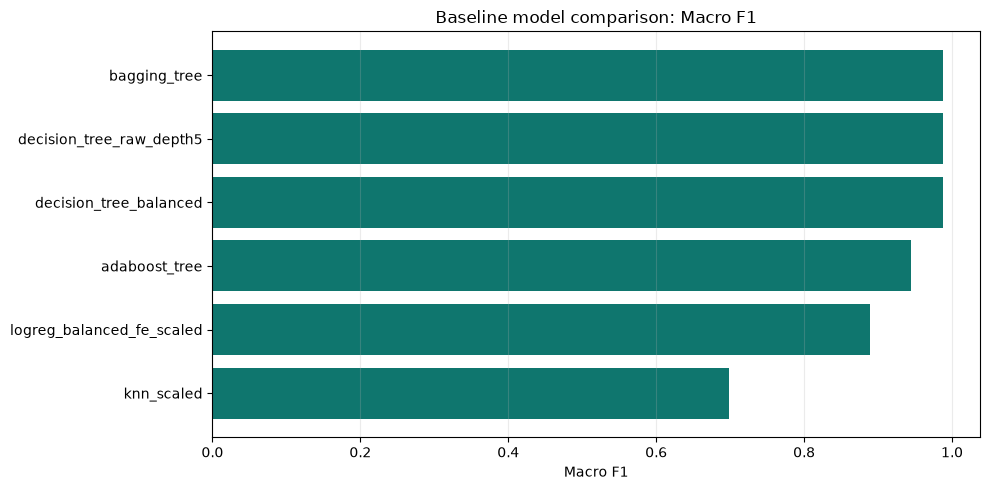

In [ ]:
display(baseline_results.sort_values("f1_macro_mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
base_plot = baseline_results.sort_values("f1_macro_mean")
ax.barh(base_plot["model_name"], base_plot["f1_macro_mean"], color="#0f766e")
ax.set_title("Baseline model comparison: Macro F1")
ax.set_xlabel("Macro F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### ماذا أعطتنا الـ Baselines؟


قوة Decision Tree الخام جعلتنا نثق أن <code>f10</code> و<code>f14</code> و<code>f12</code> ليست مجرد أعمدة مهمة إحصائياً، بل تدخل فعلياً في قواعد قرار واضحة.

لكن الشجرة الواحدة قد تكون حادة على الحدود. لذلك استفدنا منها في الفهم، بينما أبقينا القرار النهائي مبنياً على مقارنة أوسع.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 12. تفسير شجرة القرار والشرائح الصعبة


حللنا شجرة قرار بسيطة لمعرفة أين توجد الإشارة. أهمية الخصائص وقواعد الشجرة أكدتا أن الفصل بين الفئات يدور غالباً حول <code>f10</code> و<code>f14</code> مع دور واضح لـ <code>f12</code>.

بعد ذلك فحصنا الشرائح الصعبة مثل الصفوف ذات <code>f10</code> العالي و<code>f12 = 0</code>. هذه الشرائح مفيدة لأنها تكشف أين يخطئ النموذج، لا فقط كم يخطئ.


</div>


Top raw DecisionTree features:


,feature,importance
0,f10,4.916990e-01
1,f14,4.894391e-01
2,f12,1.272063e-02
3,f9,3.706601e-03
4,f17,2.051282e-03
5,f1,3.427005e-04
6,f20,4.069746e-05
7,f5,8.586021e-16
8,f4,7.596235e-16
9,f2,0.000000e+00


Raw DecisionTree rules:
|--- f14 <= 0.06
|   |--- f10 <= 0.01
|   |   |--- class: class3
|   |--- f10 >  0.01
|   |   |--- f1 <= 0.84
|   |   |   |--- f20 <= 0.14
|   |   |   |   |--- class: class1
|   |   |   |--- f20 >  0.14
|   |   |   |   |--- f9 <= 0.06
|   |   |   |   |   |--- class: class3
|   |   |   |   |--- f9 >  0.06
|   |   |   |   |   |--- class: class1
|   |   |--- f1 >  0.84
|   |   |   |--- class: class3
|--- f14 >  0.06
|   |--- f10 <= 0.01
|   |   |--- f5 <= 0.50
|   |   |   |--- class: class3
|   |   |--- f5 >  0.50
|   |   |   |--- class: class3
|   |--- f10 >  0.01
|   |   |--- f12 <= 0.50
|   |   |   |--- f9 <= 0.15
|   |   |   |   |--- f17 <= 0.50
|   |   |   |   |   |--- class: class2
|   |   |   |   |--- f17 >  0.50
|   |   |   |   |   |--- class: class3
|   |   |   |--- f9 >  0.15
|   |   |   |   |--- f1 <= 0.22
|   |   |   |   |   |--- class: class3
|   |   |   |   |--- f1 >  0.22
|   |   |   |   |   |--- class: class3
|   |   |--- f12 >  0.50
|   |   |   |--

,slice,n_rows,class1_rows,class2_rows,class3_rows,accuracy,macro_f1,balanced_accuracy
5,f10_high_q90_and_f12_equals_0,277,83,173,21,0.978339,0.939569,0.918708
4,f10_high_q90,323,92,173,58,0.981424,0.974727,0.969338
2,continuous_outlier_count_ge_1,286,53,9,224,0.993007,0.977846,0.997024
7,f12_equals_0,2807,84,191,2532,0.997506,0.991266,0.995851
0,all_rows,3200,93,191,2916,0.997812,0.991702,0.995938
3,default_binary_pattern,1367,49,101,1217,0.997074,0.992916,0.995878
1,binary_pattern_distance_ge_3,51,2,4,45,1.000000,1.000000,1.000000
6,f10_low_q10,331,0,0,331,1.000000,1.000000,1.000000
8,f12_equals_1,393,9,0,384,1.000000,1.000000,1.000000


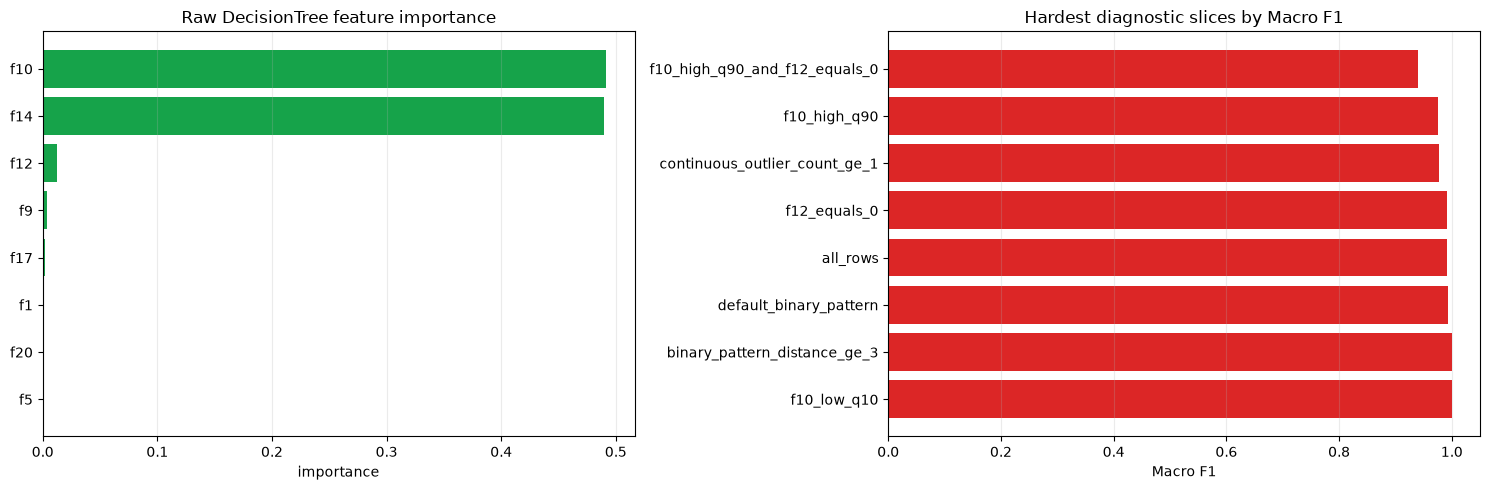

In [ ]:
raw_tree_importance = pd.read_csv(ARTIFACT_DIR / "raw_decision_tree_feature_importance.csv")
slice_diagnostics = pd.read_csv(ARTIFACT_DIR / "slice_diagnostics.csv")

with open(ARTIFACT_DIR / "raw_decision_tree_rules.txt", "r", encoding="utf-8") as f:
    raw_tree_rules = f.read()

print("Top raw DecisionTree features:")
display(raw_tree_importance.head(10))

print("Raw DecisionTree rules:")
print(raw_tree_rules)

display(slice_diagnostics.sort_values("macro_f1"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imp_plot = raw_tree_importance.head(8).iloc[::-1]
axes[0].barh(imp_plot["feature"], imp_plot["importance"], color="#16a34a")
axes[0].set_title("Raw DecisionTree feature importance")
axes[0].set_xlabel("importance")
axes[0].grid(axis="x", alpha=0.25)

slice_plot = slice_diagnostics.sort_values("macro_f1").head(8).iloc[::-1]
axes[1].barh(slice_plot["slice"], slice_plot["macro_f1"], color="#dc2626")
axes[1].set_title("Hardest diagnostic slices by Macro F1")
axes[1].set_xlabel("Macro F1")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### نتيجة تحليل الشرائح


الشرائح الصعبة تحتوي نسبة أعلى من الفئات الصغيرة، لذلك ينخفض فيها <code>Macro F1</code> مقارنة بباقي البيانات.

هذا يفسر لماذا قد تختلف ملفات الرفع في عدد قليل من الصفوف فقط، ومع ذلك يتغير السكور. هذه الصفوف غالباً تقع على حدود القرار بين الفئات.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 13. فحص الثبات عبر أكثر من تقسيم


أعدنا تقييم النماذج القوية عبر أكثر من <code>random_state</code>. الهدف أن نرى هل النموذج جيد فعلاً، أم أنه استفاد من تقسيم واحد مناسب.

النماذج التي بقيت قوية عبر seeds مختلفة هي الأكثر ثقة. في نتائجنا بقيت نماذج الأشجار والـ boosting ضمن أفضل الخيارات.


</div>


,model_name,f1_macro_mean_over_seeds,f1_macro_std_over_seeds,f1_macro_min_over_seeds,accuracy_mean_over_seeds,balanced_accuracy_mean_over_seeds
0,bagging_tree_original,0.990943,0.001494,0.989220,0.997812,0.999200
1,lightgbm_original,0.989764,0.003511,0.986767,0.997500,0.993324
2,lightgbm_eda_fe,0.988596,0.001366,0.987351,0.997083,0.998386
3,random_forest_original,0.987673,0.000977,0.986545,0.997292,0.992144
4,lightgbm_simple_fe,0.987162,0.001957,0.985121,0.996875,0.994277
5,decision_tree_raw_depth5,0.986031,0.002043,0.984070,0.997188,0.988398
6,gradient_boosting_fe,0.985604,0.003897,0.981139,0.996563,0.992278
7,hgb_simple_fe,0.983149,0.004266,0.978246,0.996354,0.985091
8,hgb_eda_fe,0.979490,0.003897,0.975645,0.995521,0.982458


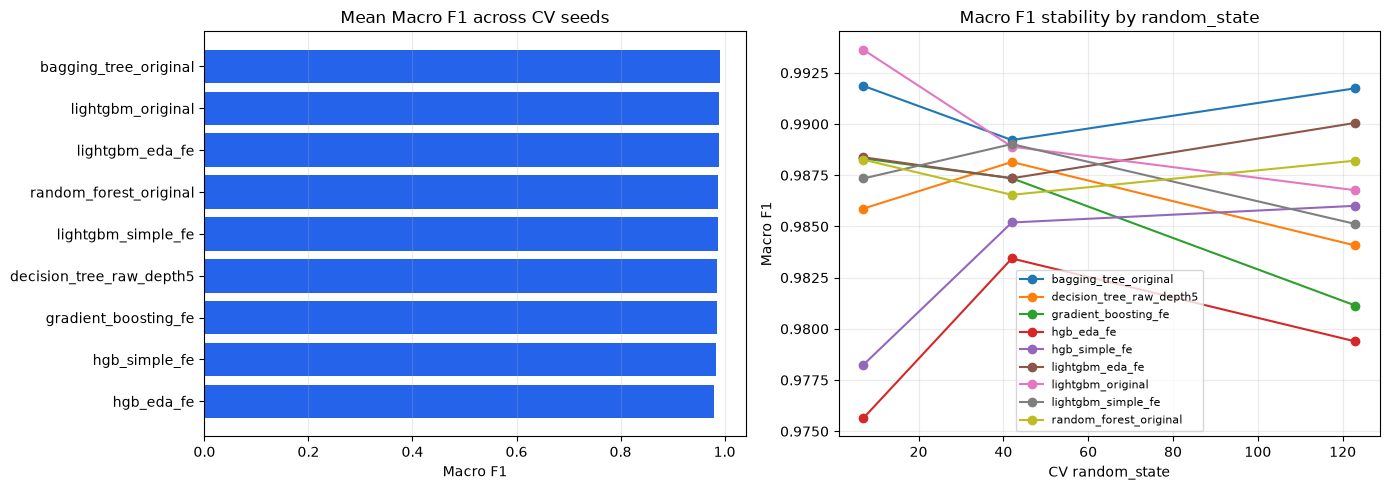

In [ ]:
display(robust_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
robust_plot = robust_summary.sort_values("f1_macro_mean_over_seeds")
axes[0].barh(robust_plot["model_name"], robust_plot["f1_macro_mean_over_seeds"], color="#2563eb")
axes[0].set_title("Mean Macro F1 across CV seeds")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

for model_name, group in robust_by_seed.groupby("model_name"):
    axes[1].plot(group["random_state"], group["f1_macro_mean"], marker="o", label=model_name)
axes[1].set_title("Macro F1 stability by random_state")
axes[1].set_xlabel("CV random_state")
axes[1].set_ylabel("Macro F1")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### ماذا أخذنا من فحص الثبات؟


فحص الثبات أعطى دعماً لاستخدام Bagging وLightGBM، لكنه لم يجعلنا نختار أعلى رقم داخلي وحده.

عندما تكون الفروقات صغيرة، يصبح توزيع التنبؤات ومصفوفة الالتباس ونتائج الملفات المرفوعة عوامل مهمة في القرار النهائي.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 14. التكرارات داخل البيانات


وجدنا صفوفاً لها نفس قيم الخصائص. بدل حذفها مباشرة، جربنا أكثر من سياسة: إبقاء الصفوف، حذف التكرار، أو ضغط الصفوف المتكررة حسب الفئة الأكثر ظهوراً.

هذا الفحص مهم لأن التكرار قد يكون نمطاً حقيقياً في البيانات، وقد يكون أيضاً سبباً يجعل التحقق الداخلي أسهل من الواقع. لذلك تركنا القرار للنتيجة الرقمية.


</div>


,rows,unique_feature_rows,exact_feature_duplicate_rows,duplicate_feature_groups,conflicting_duplicate_feature_groups,exact_feature_target_duplicate_rows
0,3200,3143,57,30,0,57


,duplicate_policy,best_f1_macro,mean_f1_macro,best_balanced_accuracy,rows_after_policy
0,feature_duplicates_majority_target,0.988314,0.961627,0.995675,3143
1,keep_all_rows,0.988148,0.966259,0.995691,3200
2,drop_feature_duplicates_keep_first,0.984652,0.965884,0.995209,3143
3,drop_exact_feature_target_duplicates_keep_first,0.984652,0.965884,0.995209,3143


,duplicate_policy,model_name,n_rows_after_policy,f1_macro_mean,balanced_accuracy_mean,accuracy_mean
12,feature_duplicates_majority_target,decision_tree_balanced_depth8,3143,0.988314,0.995675,0.997455
0,keep_all_rows,decision_tree_raw_depth5,3200,0.988148,0.992297,0.997500
1,keep_all_rows,decision_tree_balanced_depth8,3200,0.988145,0.995691,0.997500
4,drop_exact_feature_target_duplicates_keep_first,decision_tree_balanced_depth8,3143,0.984652,0.995209,0.996182
8,drop_feature_duplicates_keep_first,decision_tree_balanced_depth8,3143,0.984652,0.995209,0.996182
9,drop_feature_duplicates_keep_first,hgb_fast,3143,0.984478,0.991505,0.995545
5,drop_exact_feature_target_duplicates_keep_first,hgb_fast,3143,0.984478,0.991505,0.995545
13,feature_duplicates_majority_target,decision_tree_raw_depth5,3143,0.984399,0.988463,0.996819
10,drop_feature_duplicates_keep_first,decision_tree_raw_depth5,3143,0.983810,0.991505,0.995862
6,drop_exact_feature_target_duplicates_keep_first,decision_tree_raw_depth5,3143,0.983810,0.991505,0.995862


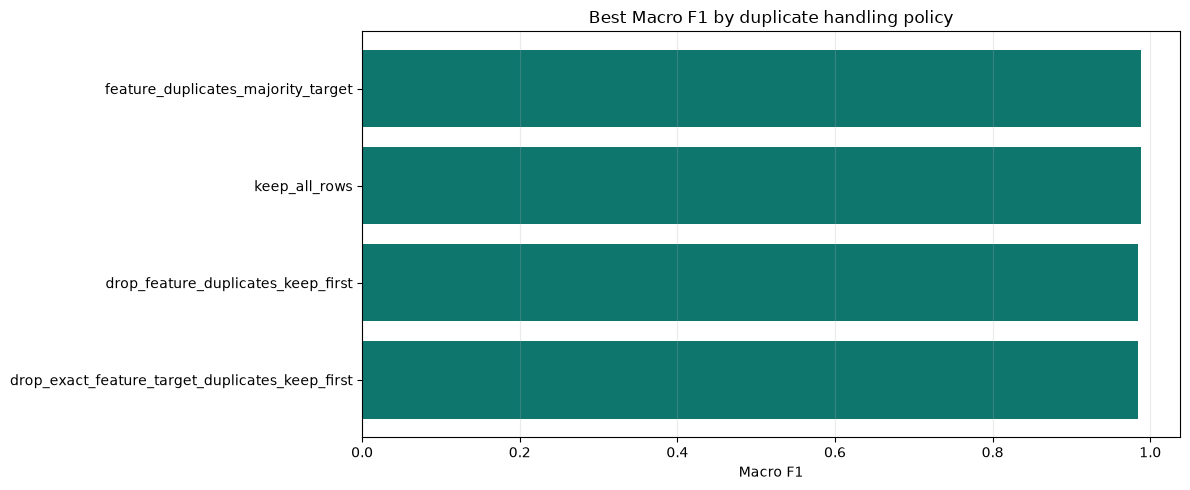

In [ ]:
display(duplicate_summary)
display(duplicate_policy_summary)

best_policy_rows = duplicate_policy_audit.sort_values("f1_macro_mean", ascending=False).head(12)
display(best_policy_rows[[
    "duplicate_policy",
    "model_name",
    "n_rows_after_policy",
    "f1_macro_mean",
    "balanced_accuracy_mean",
    "accuracy_mean",
]])

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = duplicate_policy_summary.sort_values("best_f1_macro")
ax.barh(plot_df["duplicate_policy"], plot_df["best_f1_macro"], color="#0f766e")
ax.set_title("Best Macro F1 by duplicate handling policy")
ax.set_xlabel("Macro F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### قرار التكرارات


إذا لم تعطِ سياسات الحذف تحسناً واضحاً، فإبقاء الصفوف كما هي يكون الخيار الأبسط. حذف بيانات بدون دليل قد يزيل نمطاً حقيقياً، خصوصاً في بيانات مجهولة المعنى.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 15. الصفوف الأقرب لتوزيع الاختبار


استخدمنا نموذجاً يميز بين train وtest من الخصائص فقط، ثم أخذنا الثلث من بيانات التدريب الذي يشبه الاختبار أكثر.

بعد ذلك قسنا أداء النماذج على هذه الشريحة. الهدف ليس تدريب النموذج عليها وحدها، بل معرفة هل النموذج يبقى قوياً في المنطقة الأقرب لما سنراه في الاختبار.


</div>


In [ ]:
display(test_like_slice_summary[[
    "model_name",
    "n_rows",
    "class1_rows",
    "class2_rows",
    "class3_rows",
    "macro_f1",
    "accuracy",
    "balanced_accuracy",
]].head(12))

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = test_like_slice_summary.sort_values("macro_f1").tail(12)
ax.barh(plot_df["model_name"], plot_df["macro_f1"], color="#1d4ed8")
ax.set_title("Macro F1 on the most test-like training third")
ax.set_xlabel("Macro F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### معنى فحص Test-like


هذا الفحص أعطانا زاوية مختلفة عن CV العام. نموذج ممتاز في المتوسط قد يكون أضعف على الصفوف الأقرب للاختبار.

لذلك استخدمناه كإشارة إضافية عند مقارنة الملفات المرشحة، خصوصاً عندما تكون فروقات Macro F1 صغيرة جداً.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 16. فحص أوزان الـ Ensemble


أوزان الـ ensemble قد تظهر قوية إذا اخترناها وقيمناها على نفس OOF. لذلك أضفنا فحصاً داخلياً: نختار الأوزان على جزء، ونقيسها على جزء آخر.

هذا لا يغير الملف النهائي وحده، لكنه يخبرنا هل الدمج ثابت أم حساس جداً للصفوف التي اختيرت منها الأوزان.


</div>


In [ ]:
display(nested_greedy_audit)
display(nested_greedy_weights)
display(master_comparison.head(18))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(nested_greedy_audit["fold"].astype(str), nested_greedy_audit["valid_macro_f1"], color="#0f766e")
axes[0].set_title("Nested greedy ensemble Macro F1 by fold")
axes[0].set_xlabel("fold")
axes[0].set_ylabel("Macro F1")
axes[0].grid(axis="y", alpha=0.25)

weight_plot = nested_greedy_weights.sort_values("mean_weight")
axes[1].barh(weight_plot["model_name"], weight_plot["mean_weight"], color="#f97316")
axes[1].set_title("Average selected weights in nested greedy audit")
axes[1].set_xlabel("mean weight")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### ماذا تعلمنا من فحص الأوزان؟


إذا كان أداء الدمج في الفحص الداخلي قريباً من أفضل نموذج منفرد، فهذا يعني أن الـ ensemble مفيد لكن لا يجب المبالغة في تفسير فرق صغير.

لذلك احتفظنا بعدة ملفات مرشحة، واعتبرنا نتيجة Public/Private لاحقاً دليلاً إضافياً على أي ملف كان أنسب للاختبار.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### كيف نقرأ ملفات الرفع؟


ملف الرفع الجيد ليس بالضرورة صاحب أعلى CV فقط. ننظر أيضاً إلى توزيع الكلاسات على test، وعدد الصفوف التي تختلف عن الملفات الأخرى، ونتائج Public/Private إن توفرت.

في النتائج الأخيرة كان <code>reference_soft_voting_candidate</code> من أقوى الملفات على Private، لذلك أبقيناه ظاهراً في أعلى جدول المرشحات.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 18. رسومات المقارنة


هذه الرسومات تختصر الجداول: أفضل النماذج حسب <code>Macro F1</code>، أوزان الـ ensemble، ثم مصفوفة الالتباس النهائية.

لا نعرض مصفوفة لكل موديل هنا حتى لا يصبح النوتبوك مزدحماً. كل المصفوفات محفوظة في <code>model_oof_confusion_matrices.csv</code>، ونستخدم الرسم هنا لفهم النموذج النهائي بسرعة.


</div>


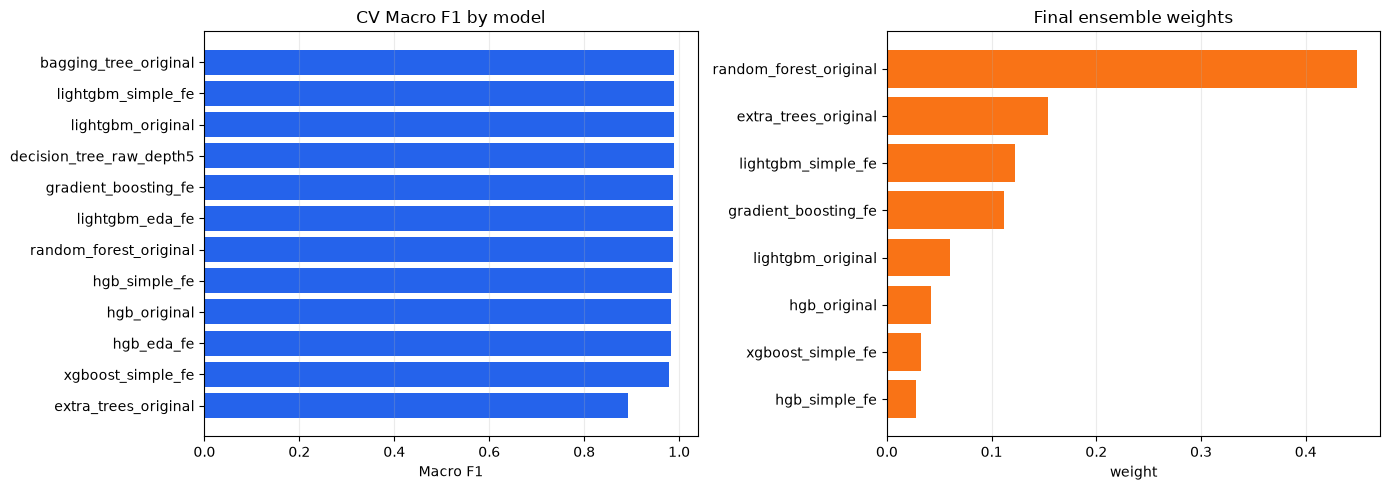

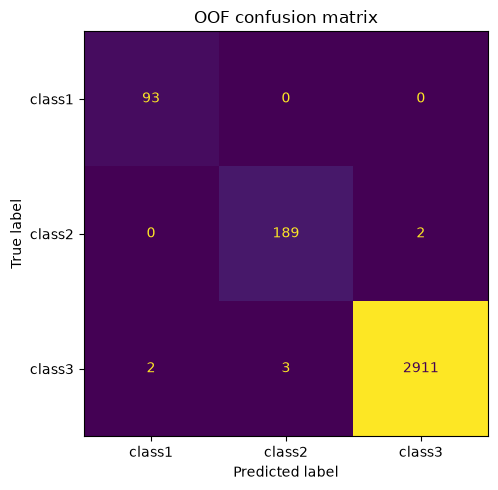

In [ ]:
cv_results = pd.read_csv(ARTIFACT_DIR / "cv_results.csv")
ensemble_info = json.loads((ARTIFACT_DIR / "ensemble_info.json").read_text(encoding="utf-8"))
cm_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv", index_col=0)
class_names = [c.replace("true_", "") for c in cm_df.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df = cv_results.sort_values("f1_macro_mean", ascending=False).head(10).sort_values("f1_macro_mean")
axes[0].barh(plot_df["model_name"], plot_df["f1_macro_mean"], color="#2563eb")
axes[0].set_title("Top models by CV Macro F1")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)
for idx, value in enumerate(plot_df["f1_macro_mean"]):
    axes[0].text(value + 0.00015, idx, f"{value:.4f}", va="center", fontsize=9)

weights_df = pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight")
axes[1].barh(weights_df["model"], weights_df["weight"], color="#f97316")
axes[1].set_title("Final ensemble weights")
axes[1].set_xlabel("weight")
axes[1].grid(axis="x", alpha=0.25)
for idx, value in enumerate(weights_df["weight"]):
    axes[1].text(value + 0.005, idx, f"{value:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_df.values, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Final ensemble OOF confusion matrix")
for i in range(cm_df.shape[0]):
    for j in range(cm_df.shape[1]):
        value = int(cm_df.values[i, j])
        color = "white" if value > cm_df.values.max() * 0.55 else "black"
        ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### قراءة الرسومات


تقارب الأعمدة في رسم <code>Macro F1</code> يوضح أن عدة نماذج قوية جداً. لذلك كان القرار النهائي مبنياً على مجموعة أدلة لا على ترتيب واحد.

مصفوفة الالتباس توضح أن معظم الصفوف سهلة، وأن الأخطاء المهمة قليلة ومركزة حول الفئات الصغيرة. هذه الأخطاء القليلة هي التي صنعت الفرق بين ملفات الرفع.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 19. فحص ملف الرفع


نفحص ملف <code>submission.csv</code> من ناحية الشكل: الأعمدة، عدد الصفوف، ترتيب <code>ID</code>، وعدم وجود قيم فارغة.

ثم نعرض توزيع التنبؤات. التوزيع القريب من التدريب ليس شرطاً كافياً، لكنه مؤشر أن النموذج لا ينهار إلى فئة واحدة ولا يبالغ في توقع الفئات الصغيرة.


</div>


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


target
class1      81
class2     188
class3    2931
Name: count, dtype: int64

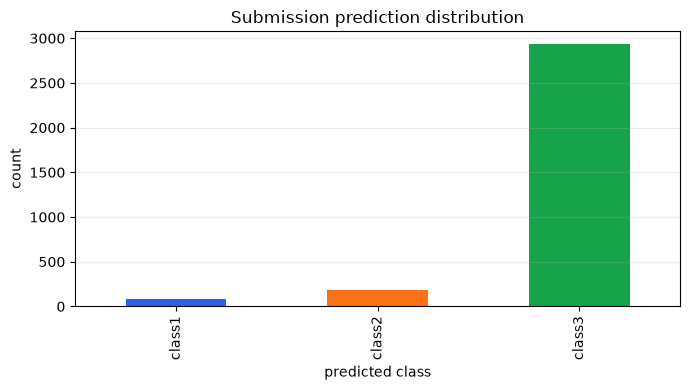

In [ ]:
assert list(submission.columns) == [ID_COL, TARGET_COL]
assert submission[ID_COL].tolist() == sample_submission[ID_COL].tolist()
assert submission[TARGET_COL].notna().all()
assert set(submission[TARGET_COL].unique()).issubset(set(class_names))

display(submission.head())
display(submission[TARGET_COL].value_counts().sort_index().rename("count"))

fig, ax = plt.subplots(figsize=(7, 4))
submission[TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Submission prediction distribution")
ax.set_xlabel("predicted class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

### خلاصة ملف الرفع


ملف <code>submission.csv</code> صحيح من ناحية الصيغة، وتوزيعه منطقي مقارنة بالتدريب.

بالإضافة إلى الملف النهائي، احتفظنا بملفات مرشحة أخرى داخل <code>model_submissions</code> لأن نتائج الرفع أوضحت أن بعض الملفات القريبة جداً داخلياً قد تختلف على Public/Private.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 20. Public و Private


بعد ظهور النتائج، اتضح أن بعض الملفات المتقاربة داخلياً تعطي نتائج مختلفة على Public وPrivate. هذا طبيعي في مسابقة فيها split مخفي: اختلاف بضع صفوف عند الحدود قد يغير السكور.

لذلك لا نفسر نتيجة Public وحدها كحقيقة نهائية. نستخدمها مع CV، ومع فحوص الثبات، ومع ملفات الرفع المرشحة. عندما أعطى <code>reference_soft_voting_candidate</code> نتيجة Private قوية، كان مهماً أن يكون هذا الملف مولداً من الكود وموثقاً داخل artifacts.


</div>


<div dir="rtl" style="font-family: Tahoma, Arial, sans-serif; direction:rtl; text-align:right; line-height:1.75; font-size:15.5px; color:inherit;">

## 21. MLflow و DVC


استخدمنا MLflow كسجل للتجارب: كل نموذج له مقاييسه، وإعداداته، وبعض الملفات الناتجة عنه. هذا يساعدنا على تتبع ما جربناه بدل الاعتماد على الذاكرة.

واستخدمنا DVC لتتبع ملفات البيانات الكبيرة خارج Git. في Git تبقى ملفات <code>.dvc</code> الصغيرة، ويمكن لأي عضو في الفريق استرجاع البيانات عبر <code>dvc pull</code>.


</div>
